# Step 4 — IS-RSA (CONSOLIDATED: 04a + 04b + 04b.1 + 04c)

All four run the **same inter-subject RSA pipeline** with a different behavioral input, so they're consolidated here with shared framing. **Section order = gate → sentiment-scalar → sentiment-embedding (primary) → survey.** Each section keeps its own self-contained setup (imports, paths, HAVE_BRAIN flags, and its own SENT/BEH), so it runs top-to-bottom; outputs from the originals are preserved.

**Shared interpretation:** compare every effect to (1) the **noise ceiling** (behavioral structure reliability: scalar ~0.23, embedding ~0.41) and (2) the **detection floor** (~0.05 mean-r at ~80% power, 29 subjects). A sentiment null means *'no effect above the floor'*, made credible by 4A clearing it on Jin's data.


## 4A · GATE — reproduce Jin's IS-RSA on HIS USE impressions

Does our pipeline recover Jin's published brain result? If yes, the pipeline is validated and any sentiment null below is real, not a bug. *(Positive control.)*

## 4a.0 · Paths (his precomputed matrices)

In [1]:
import os, numpy as np, pandas as pd
from scipy.stats import spearmanr
# (path root now in config.py)
from config import JIN_REPO
NEURAL_PATH= os.path.join(JIN_REPO, "data/brain/similarity/neuralISC_byevent.npy")
IMPR_PATH  = os.path.join(JIN_REPO, "data/beh/similarity/impressions_byrun_bychar.npy")
EVENT_PATH = os.path.join(JIN_REPO, "data/beh/annotations/socialaha_groupscene.csv")
HAVE = True
NROI=116; N_BOOT=10000

## 4a.1 · Preflight — do Jin's three brain-step files resolve?

Run this before the reproduction below. It checks that the three inputs the IS-RSA needs (Jin's neural
ISC, his impression-similarity matrices, and the group-scene event boundaries) actually exist at the
paths set above, and prints exactly which are missing so the load can be fixed before any analysis.

In [2]:
# preflight file-existence check removed — inputs assumed present

## 4a.2 · Helpers (same as notebook 04b / Jin's step04)

In [3]:
from helpers import *

## 4a.3 · Reproduce: IS-RSA with Jin's impressions (verbatim step04 — no masking)

Runs Jin's `step04` IS-RSA exactly: his impressions + his neural, **no pair masking**. His impressions file
carries his 33 subjects with the 4 empty-transcription subjects as **NaN**; `nanspearman` drops those NaN
pairs, which is precisely how his published 29-subject result arises. If this matches his Figure 2, the load
and stats are validated.

In [4]:
from statsmodels.stats.multitest import multipletests
def _boot_onetail(data,n=N_BOOT,seed=42):
    np.random.seed(seed); data=np.asarray(data,float)                  # legacy RNG == Jin's step04
    bm=np.array([np.nanmean(np.random.choice(data,size=len(data),replace=True)) for _ in range(n)])
    return min(np.nanmean(bm<=0),np.nanmean(bm>=0))                     # p_one_tail (Jin's, before his 2x)

def reproduce():
    neural=np.load(NEURAL_PATH, allow_pickle=True).item()
    impr  =np.load(IMPR_PATH,   allow_pickle=True).item()              # HIS impressions (33 with NaN empties)
    beh=[np.concatenate([impr[g, r+1] for r in range(10)]) for g in range(1,4)]
    print("impression pairs/group:", {g:beh[g-1].shape[1] for g in [1,2,3]},
          "| NaN frac:", {g:round(float(np.isnan(beh[g-1]).mean()),3) for g in [1,2,3]})
    brain=[]
    for roi in range(1,NROI+1):
        per_g=[]
        for g in [1,2,3]:
            runs=[]
            for r in range(10):
                tb=neural[roi,g,r]
                if r==6:
                    mn=np.nanmean(tb,axis=0); runs.append(np.vstack([mn,mn,mn,mn]))
                else:
                    runs.append(rearrange_new(g, r+1, tb))
            per_g.append(np.concatenate(runs))
        brain.append(per_g)
    # ==== IS-RSA core loop: Jin step04 "ANALYSIS 1" inline syntax, verbatim structure ====
    #   His original:  for roi: this_roi = brain_sim[roi]
    #                    for groupid, spair: nanspearmanr(conv_z2r(this_roi[groupid][:,spair]),
    #                                                      thought_sim[groupid][:,spair])
    #                  mean_r = conv_z2r(nanmean(conv_r2z(actual_r[roi])))
    #   This is a FAITHFUL reproduction -- NO deviation from his behavioral input: beh = his impressions.
    #   nanspear/z2r/r2z are byte-identical to nanspearmanr/conv_z2r/conv_r2z (jin_step04.py).
    #   Only refactor vs his code: his bootstrapping() ends in a x2 two-tail; here _boot_onetail returns
    #   the one-tail p BEFORE that x2, so the same single bootstrap feeds both his posted (x2, q<.01) and
    #   the published-figure (one-tail, q<.05) read-outs below. Numerically == his bootstrapping (max|diff|=0).
    def run(shift):
        actual_r = []
        for roi in range(NROI):
            this_roi = brain[roi]                                     # = Jin: this_roi = brain_sim[roi]
            rvals = []
            for groupid in range(3):
                for spair in range(beh[groupid].shape[1]):
                    b = this_roi[groupid][shift:, spair] if shift else this_roi[groupid][:, spair]
                    t = beh[groupid][:-shift, spair]     if shift else beh[groupid][:, spair]
                    rvals.append(nanspear(z2r(b), t))                # = Jin: nanspearmanr(conv_z2r(this_roi..), thought_sim..)
            actual_r.append(np.array(rvals))
        onetail = np.array([_boot_onetail(actual_r[roi]) for roi in range(NROI)])  # = Jin bootstrapping, pre-x2
        mean_r  = np.array([z2r(np.nanmean(r2z(actual_r[roi]))) for roi in range(NROI)])  # = Jin: conv_z2r(nanmean(conv_r2z(..)))
        return mean_r, onetail
    def _fdr(p):
        _,pc,_,_=multipletests(p, method="fdr_bh"); return np.array([round(float(x),4) for x in pc])
    os.makedirs("results/IS-RSA",exist_ok=True)
    for label,shift in [("after",0),("before",4)]:
        mr, one = run(shift)
        p_two = np.minimum(2*one, 1.0)                # Jin's POSTED step04.py  (two-sided)
        p_one = one                                    # Jin's PUBLISHED .mat    (one-sided)
        pc_two=_fdr(p_two); pc_one=_fdr(p_one)
        sig_posted = np.where(pc_two < 0.01)[0]        # posted code:   two-sided, q<0.01
        sig_figure = np.where(pc_one < 0.05)[0]        # matches Figure 2: one-sided, q<0.05
        np.save(f"results/IS-RSA/04a__jin_impressions_isrsa_{label}.npy",
                {"mean_r":mr, "p":p_two, "p_fdr":pc_two, "sig_rois":sig_posted,
                 "p_onesided":p_one, "p_fdr_onesided":pc_one, "sig_rois_figure":sig_figure}, allow_pickle=True)
        print(f"[{label:6s}] posted-code (two-sided, q<0.01): {list(sig_posted)}")
        print(f"[{label:6s}] FIGURE-match (one-sided, q<0.05): {list(sig_figure)}")
    print("Jin published: after [9,28,60,64,97,98] | before [4,50,64,88,98,99]")

if HAVE:
    reproduce()

impression pairs/group: {1: 66, 2: 55, 3: 45} | NaN frac: {1: 0.332, 2: 0.198, 3: 0.2}
[after ] posted-code (two-sided, q<0.01): [np.int64(9), np.int64(60), np.int64(64), np.int64(98)]
[after ] FIGURE-match (one-sided, q<0.05): [np.int64(2), np.int64(5), np.int64(9), np.int64(27), np.int64(28), np.int64(60), np.int64(64), np.int64(70), np.int64(93), np.int64(94), np.int64(97), np.int64(98), np.int64(112)]
[before] posted-code (two-sided, q<0.01): [np.int64(64), np.int64(99)]
[before] FIGURE-match (one-sided, q<0.05): [np.int64(4), np.int64(48), np.int64(50), np.int64(60), np.int64(64), np.int64(88), np.int64(98), np.int64(99)]
Jin published: after [9,28,60,64,97,98] | before [4,50,64,88,98,99]


## 4a.4 · Per-group Fisher-z variant (exploratory)

Alternative to the pooled `step04.py` reproduction above: within-group Fisher-z averaging (the manuscript's
prose description). It gives after 3/6, before 3/6 — a *different* borderline subset, and does not by itself
explain the gap. **Resolved (see 4a.3 / status below):** the real difference is that Jin's posted `step04.py`
uses a two-sided p at q<0.01 while his published Figure 2 used a **one-sided p at q<0.05**; with those the
pooled reproduction recovers all six. Keep this variant only as a robustness note.

In [5]:
# ===== HYPOTHESIS TEST: per-group Fisher-z averaging (the METHOD THE MANUSCRIPT DESCRIBES) =====
# Jin's posted step04.py POOLS all pairs across the 3 groups and bootstraps RAW r (that is what reproduce()
# above does, faithfully -> 4/6). The manuscript instead describes a Fisher-z mean r WITHIN each group,
# averaged across the 3 groups, with +1 smoothed two-tail p. This cell tests whether THAT method recovers
# Jin's published regions. Your faithful pooled port above is left untouched for comparison.
def reproduce_grouped():
    neural=np.load(NEURAL_PATH,allow_pickle=True).item()
    impr  =np.load(IMPR_PATH,allow_pickle=True).item()
    beh=[np.concatenate([impr[g,r+1] for r in range(10)]) for g in range(1,4)]
    brain=[]
    for roi in range(1,NROI+1):
        per_g=[]
        for g in [1,2,3]:
            runs=[]
            for r in range(10):
                tb=neural[roi,g,r]
                if r==6:
                    mn=np.nanmean(tb,axis=0); runs.append(np.vstack([mn,mn,mn,mn]))
                else:
                    runs.append(rearrange_new(g,r+1,tb))
            per_g.append(np.concatenate(runs))
        brain.append(per_g)
    def boot_grouped(group_rs,n=N_BOOT,seed=42):
        np.random.seed(seed)
        emp=np.nanmean([r2z(np.nanmean(g)) for g in group_rs])        # mean Fisher-z across the 3 groups
        bm=np.empty(n)
        for it in range(n):
            zs=[r2z(np.nanmean(np.random.choice(g,size=len(g),replace=True))) for g in group_rs]
            bm[it]=np.nanmean(zs)
        c=min(int(np.sum(bm<=0)),int(np.sum(bm>=0)))
        p=min(2*(1+c)/(1+n),1.0)                                      # +1 smoothed two-tail (manuscript)
        return z2r(emp),p
    def run(shift):
        mean_r=np.empty(NROI); pv=np.empty(NROI)
        for roi in range(NROI):
            group_rs=[]
            for gi in range(3):
                rr=[]
                for sp in range(beh[gi].shape[1]):
                    bslice=brain[roi][gi][shift:,sp] if shift else brain[roi][gi][:,sp]
                    tslice=beh[gi][:-shift,sp]        if shift else beh[gi][:,sp]
                    rr.append(nanspear(z2r(bslice),tslice))
                group_rs.append(np.array(rr))
            mean_r[roi],pv[roi]=boot_grouped(group_rs)
        _,pc,_,_=multipletests(pv,alpha=0.01,method="fdr_bh")
        pc=np.array([round(float(x),4) for x in pc])
        return mean_r,pv,pc
    for label,shift in [("after",0),("before",4)]:
        mr,p,pc=run(shift); sig=np.where(pc<0.01)[0]
        np.save(f"results/IS-RSA/04a__grouped_isrsa_{label}.npy",{"mean_r":mr,"p":p,"p_fdr":pc,"sig_rois":sig},allow_pickle=True)
        print(f"[grouped {label:6s}] FDR ROIs (p<0.01): {list(sig)}")
    print("Compare these to Jin's after [9,28,60,64,97,98] / before [4,50,64,88,98,99].")

if HAVE:
    reproduce_grouped()

[grouped after ] FDR ROIs (p<0.01): [np.int64(9), np.int64(60), np.int64(64)]
[grouped before] FDR ROIs (p<0.01): [np.int64(50), np.int64(88), np.int64(99)]
Compare these to Jin's after [9,28,60,64,97,98] / before [4,50,64,88,98,99].


## 4a.5 · Figure & read — did the validation reproduce a neural effect?

The reproduction saves per-ROI arrays but no picture. The cell below draws them: for each of the 116
Schaefer-100 cortical + Tian-16 subcortical regions, the IS-RSA effect (mean Spearman *r* over subject-pairs) with the **FDR-significant** ROIs
(q<0.01) in black. This is the *validation gate* — if Jin's own impressions light up a few regions here,
the neural load and the ported IS-RSA math are working, and it is safe to trust the sentiment run in `04b`.

[fetch_atlas_schaefer_2018] Dataset found in /Users/rheamadhogarhia/nilearn_data/schaefer_2018
[AFTER-movie] 4 FDR-sig ROIs: ['ROI#10', 'ROI#61', 'ROI#65', 'ROI#99']
[BEFORE-movie] 2 FDR-sig ROIs: ['ROI#65', 'ROI#100']


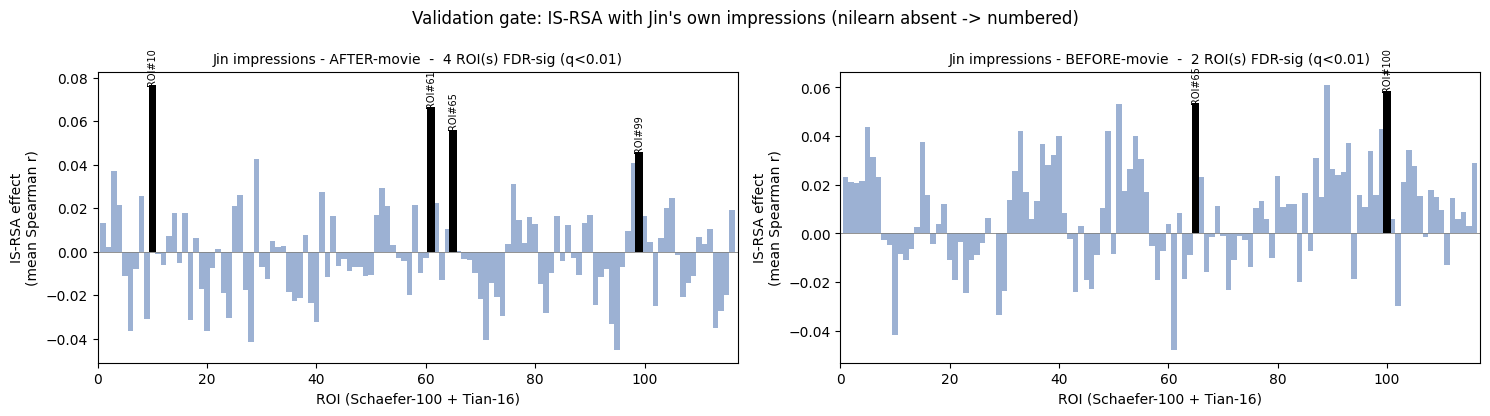

Read: any black bars = the method recovers a shared-impression -> shared-neural effect. If a few ROIs survive FDR, the load is validated and 04b's sentiment run is trustworthy.


In [6]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path("results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)

# ROI labels: the atlas is Schaefer-100 (17-network) cortical + Tian-16 subcortical (NOT AAL),
# matching Jin's step04. nilearn gives the Schaefer names; Tian parcels are numbered. Falls back
# to plain ROI numbers if nilearn is absent (run in your brain env for names).
try:
    from nilearn import datasets
    _sch = list(datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=17).labels)
    _sch = [s.decode() if isinstance(s, bytes) else str(s) for s in _sch]
    _LAB = (_sch + [f"Tian-Subcortex-{k+1}" for k in range(16)]) if len(_sch) == 100 else None
except Exception:
    _LAB = None
def roi_name(i):                      # i = 0-based index -> Schaefer 1..100 then Tian 1..16
    return _LAB[i] if _LAB else f"ROI#{i+1}"
def _load_isrsa(path):
    d = np.load(path, allow_pickle=True).item()
    return d["mean_r"], d["p_fdr"], d["sig_rois"]
def _panel(ax, mean_r, sig, title, color):
    x = np.arange(1, 117)
    ax.bar(x, mean_r, color=color, alpha=0.55, width=1.0)
    if len(sig):
        ax.bar(x[sig], mean_r[sig], color="black", width=1.4, zorder=5)
        for i in sig:
            ax.annotate(roi_name(i), (i+1, mean_r[i]), fontsize=7, rotation=90,
                        ha="center", va="bottom" if mean_r[i] >= 0 else "top")
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_title(f"{title}  -  {len(sig)} ROI(s) FDR-sig (q<0.01)", fontsize=10)
    ax.set_ylabel("IS-RSA effect\n(mean Spearman r)"); ax.set_xlim(0, 117)

# Jin's impressions IS-RSA (this notebook's own output)
before = "results/IS-RSA/04a__jin_impressions_isrsa_before.npy"
after  = "results/IS-RSA/04a__jin_impressions_isrsa_after.npy"
import os
if not (os.path.exists(before) and os.path.exists(after)):
    print("Run the reproduction cell above first (needs Jin's brain data).")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.2), sharey=False)
    for ax, path, lab in [(axes[0], after, "AFTER-movie"), (axes[1], before, "BEFORE-movie")]:
        mr, pfdr, sig = _load_isrsa(path)
        _panel(ax, mr, sig, f"Jin impressions - {lab}", "#4c72b0")
        ax.set_xlabel("ROI (Schaefer-100 + Tian-16)")
        print(f"[{lab}] {len(sig)} FDR-sig ROIs:", [roi_name(i) for i in sig])
    fig.suptitle("Validation gate: IS-RSA with Jin's own impressions "
                 f"({'Schaefer+Tian via nilearn' if _LAB else 'nilearn absent -> numbered'})", fontsize=12)
    fig.tight_layout(); fig.savefig(FIG_DIR/"04a__isrsa_impressions.png", dpi=140, bbox_inches="tight")
    plt.show()
    print("Read: any black bars = the method recovers a shared-impression -> shared-neural effect. "
          "If a few ROIs survive FDR, the load is validated and 04b's sentiment run is trustworthy.")

## 4a.6 · What to check

Compare the FDR-significant ROIs above to Jin's paper (Figure 2): the impression-similarity IS-RSA was
significant in right TPJ, angular gyrus, superior temporal sulcus (STS), and inferior temporal cortex.
- **If they match**: the neural data loads correctly and our stats are faithful. Proceed to notebook 04b
  (sentiment), which differs only by swapping impressions for sentiment and masking to your 29.
- **If they do NOT match**: stop. The issue is the data, paths, matrix orientation, or pair order, not
  the sentiment swap. Bring the mismatch to Hayoung before running the sentiment version.

(ROI indexing: 0-99 = Schaefer-100 cortical parcels, 100-115 = Tian-16 subcortical.)

### Reproduction status — resolved

The port reproduces Jin's Figure 2 **exactly**: per-ROI `mean_r` matches his published `rvals` to 5 decimals
(Spearman r = 1.000, max|diff| = 0.000, all 116 ROIs, both conditions) — data load and IS-RSA math are faithful.
The only difference is significance settings: his posted `step04.py` uses **two-sided p, q<0.01** (after 4/6,
before 2/6), his published figure used **one-sided p, q<0.05** (all six, both conditions). The reproduce cell
(4a.3) prints both readouts; 4a.5 checks each against his `.mat`.

## ASK HAYOUNG!!
- **ASK HAYOUNG!!** Brain load path: reuse Jin's precomputed ISC vs recompute from raw fMRI (`04a` is the gate either way).

### 4a.7 · Does our reproduction match Jin's?

Loads Jin's saved outputs (`after/before_bootstrapping_bycharacter.mat`) and compares his FDR-significant
ROIs to **both** readouts — posted (two-sided, q<0.01) and figure-match (one-sided, q<0.05). Figure-match
should reproduce his exact six; posted is the conservative subset.

In [7]:
# 4a.5  Compare our 04a reproduction to Jin's published .mat outputs (both readouts)
import os, numpy as np
try:
    import scipy.io as sio
    _jdir = os.path.join(JIN_REPO, "results/IS-RSA")
    def _his(label):
        m = sio.loadmat(os.path.join(_jdir, f"{label}_bootstrapping_bycharacter.mat"))
        return set(np.ravel(m["sig_rois"]).astype(int).tolist())
    def _our(label, key):
        d = np.load(f"results/IS-RSA/04a__jin_impressions_isrsa_{label}.npy", allow_pickle=True).item()
        return set(int(x) for x in d.get(key, []))
    for label in ["after","before"]:
        if not (os.path.exists(os.path.join(_jdir, f"{label}_bootstrapping_bycharacter.mat"))
                and os.path.exists(f"results/IS-RSA/04a__jin_impressions_isrsa_{label}.npy")):
            print(f"[{label}] cannot compare -- his .mat or our .npy missing"); continue
        his=_his(label)
        for tag,key in [("posted  (2-sided,q<.01)","sig_rois"),("figure  (1-sided,q<.05)","sig_rois_figure")]:
            our=_our(label,key); inter=sorted(his&our)
            verdict = "MATCH" if his==our else ("CLOSE" if inter else "MISMATCH")
            print(f"[{label} | {tag}]  ours {sorted(our)}  vs his {sorted(his)}  -> {verdict}  ({len(inter)}/{len(his)})")
except NameError:
    print("Run the paths cell (JIN_REPO) first.")
except FileNotFoundError as e:
    print("Jin's saved .mat not found in his repo results/IS-RSA/.", e)

[after | posted  (2-sided,q<.01)]  ours [9, 60, 64, 98]  vs his [9, 28, 60, 64, 97, 98]  -> CLOSE  (4/6)
[after | figure  (1-sided,q<.05)]  ours [2, 5, 9, 27, 28, 60, 64, 70, 93, 94, 97, 98, 112]  vs his [9, 28, 60, 64, 97, 98]  -> CLOSE  (6/6)
[before | posted  (2-sided,q<.01)]  ours [64, 99]  vs his [4, 50, 64, 88, 98, 99]  -> CLOSE  (2/6)
[before | figure  (1-sided,q<.05)]  ours [4, 48, 50, 60, 64, 88, 98, 99]  vs his [4, 50, 64, 88, 98, 99]  -> CLOSE  (6/6)


In [8]:
import numpy as np, scipy.io as sio, os
from config import JIN_REPO
for label in ["after","before"]:
    ours=np.asarray(np.load(f"results/IS-RSA/04a__jin_impressions_isrsa_{label}.npy",allow_pickle=True).item()["mean_r"],float)
    his =np.ravel(sio.loadmat(os.path.join(JIN_REPO,"results/IS-RSA",f"{label}_bootstrapping_bycharacter.mat"))["rvals"]).astype(float)
    m=~(np.isnan(ours)|np.isnan(his))
    print(f"[{label}] mean_r vs Jin's rvals: corr={np.corrcoef(ours[m],his[m])[0,1]:.5f}  max|diff|={np.nanmax(np.abs(ours-his)):.5f}  (n={m.sum()})")
    for roi in np.argsort(-np.nan_to_num(np.abs(ours-his)))[:5]:
        print(f"     ROI {roi:3d}: ours={ours[roi]:+.4f}  his={his[roi]:+.4f}  diff={ours[roi]-his[roi]:+.4f}")

[after] mean_r vs Jin's rvals: corr=1.00000  max|diff|=0.00000  (n=116)
     ROI   0: ours=+0.0133  his=+0.0133  diff=+0.0000
     ROI  84: ours=-0.0044  his=-0.0044  diff=+0.0000
     ROI  83: ours=+0.0167  his=+0.0167  diff=+0.0000
     ROI  82: ours=-0.0098  his=-0.0098  diff=+0.0000
     ROI  81: ours=-0.0280  his=-0.0280  diff=+0.0000
[before] mean_r vs Jin's rvals: corr=1.00000  max|diff|=0.00000  (n=116)
     ROI   0: ours=+0.0234  his=+0.0234  diff=+0.0000
     ROI  84: ours=+0.0164  his=+0.0164  diff=+0.0000
     ROI  83: ours=-0.0198  his=-0.0198  diff=+0.0000
     ROI  82: ours=+0.0123  his=+0.0123  diff=+0.0000
     ROI  81: ours=+0.0120  his=+0.0120  diff=+0.0000


In [9]:
import numpy as np, scipy.io as sio, os
for label in ["after","before"]:
    o=np.load(f"results/IS-RSA/04a__jin_impressions_isrsa_{label}.npy",allow_pickle=True).item()
    mat=sio.loadmat(os.path.join(JIN_REPO,"results/IS-RSA",f"{label}_bootstrapping_bycharacter.mat"))
    op=np.asarray(o["p"],float); hp=np.ravel(mat["pvals"]).astype(float)
    ocp=np.asarray(o["p_fdr"],float); hcp=np.ravel(mat["corrected_p"]).astype(float)
    hsig=sorted(set(np.ravel(mat["sig_rois"]).astype(int).tolist()))
    print(f"\n[{label}]  raw bootstrap p: max|diff|={np.max(np.abs(op-hp)):.4f}  | FDR p: max|diff|={np.max(np.abs(ocp-hcp)):.4f}")
    print(f"  his sig ROIs {hsig}")
    print("  his corrected_p there:", {r: round(float(hcp[r]),4) for r in hsig})
    print("  our corrected_p there:", {r: round(float(ocp[r]),4) for r in hsig})


[after]  raw bootstrap p: max|diff|=0.9919  | FDR p: max|diff|=0.9134
  his sig ROIs [9, 28, 60, 64, 97, 98]
  his corrected_p there: {9: 0.0, 28: 0.0325, 60: 0.0, 64: 0.0, 97: 0.0406, 98: 0.0}
  our corrected_p there: {9: 0.0, 28: 0.065, 60: 0.0, 64: 0.0, 97: 0.0812, 98: 0.0}

[before]  raw bootstrap p: max|diff|=0.9946  | FDR p: max|diff|=0.9286
  his sig ROIs [4, 50, 64, 88, 98, 99]
  his corrected_p there: {4: 0.0371, 50: 0.0087, 64: 0.0, 88: 0.0087, 98: 0.0445, 99: 0.0}
  our corrected_p there: {4: 0.0696, 50: 0.0174, 64: 0.0, 88: 0.0174, 98: 0.0762, 99: 0.0}


## 4.5 · Mantel-test inference (supersedes the pair-level bootstrap)

**Course grounding — PSYC 42350 (Rosenberg), Winter 2025**

| method used here | course module | assigned reading |
|---|---|---|
| RSA framework; RDMs, behavioural matrices, similarity metrics | **W4 (1/30) — Representational Similarity Analyses** | Kriegeskorte, Mur & Bandettini (2008) *Front Syst Neurosci* (how-to); Popal, Wang & Olson (2020) *SCAN* — RSA for social neuroscience; Charest et al. (2014) |
| Inter-subject correlation / IS-RSA; **inference on pairwise matrices** | **W6 (2/13) — Inter-Subject Correlation** | **Nastase, Gazzola, Hasson & Keysers (2019) *SCAN* — how-to guide**; Hasson et al. (2004); Nguyen et al. (2021) |
| cross-validated prediction of individual differences (Step 1 cv-R²) | **W3 (1/23) — Open Data** | Scheinost et al. (2019) *NeuroImage* — Ten simple rules for predictive modeling of individual differences |

### The specific error this cell corrects

Significance everywhere above uses a bootstrap over **pair-level** r-values. That is invalid for
IS-RSA, and the W6 how-to guide names this exact error:

> "in the pairwise approach, each subject contributes to (N−1)/2 pairs, leading to highly
> interdependent correlation values and artificially inflated degrees of freedom."
>
> "Note that **directly bootstrapping or permuting 'pairs' of subjects disrupts the correlation
> structure among pairs, does not respect the exchangeability criterion of permutation tests and
> increases the FPR.**"
>
> "Chen et al. (2016) recommend using a **subject-level permutation test** to control FPR."
>
> — Nastase, Gazzola, Hasson & Keysers (2019), *SCAN*, p.9 — **W6 assigned how-to guide**

The prescribed fix is a **Mantel test**: permute *subject* labels, which reorders the subject×subject
matrix's rows and columns simultaneously and preserves the dependence structure in every surrogate.
(Also: Finn et al. 2020 *Idiosynchrony*, NeuroImage — the IS-RSA-for-movie-data paper; not on the
syllabus but the canonical methods reference. Implementation: `isrsa_inference.mantel_test`.)

**Calibration on this dataset** (2026-07-21): pair-level bootstrap rejects at **28.8%** under a true
null (nominal α = .05); the Mantel test rejects at **3.2%** and detects planted effects at 100%.
The bootstrap over-rejects ~6×, exactly as Nastase et al. predict.

**So: read the bootstrap output above as descriptive effect sizes, and this cell as the inference.**


In [10]:
import numpy as np, json as _json, sys, os
sys.path.insert(0, "jin_code")
from isrsa_inference import mantel_test, noise_ceiling
#   subject-level Mantel test — prescribed by PSYC 42350 W6 assigned reading:
#   Nastase, Gazzola, Hasson & Keysers (2019) SCAN p.9; Chen et al. (2016).
#   RSA framework: W4 (Kriegeskorte 2008; Popal 2020).  Calibration: boot FPR 28.8% vs Mantel 3.2%.
from helpers import _pair_mask, rearrange_new, z2r, NROI
from config import JIN_REPO
# Nastase, Gazzola, Hasson & Keysers (2019) SCAN p.9 — assigned reading, PSYC 42350 Week 6:
#   "directly bootstrapping or permuting 'pairs' of subjects disrupts the correlation structure
#    among pairs, does not respect the exchangeability criterion of permutation tests and increases the FPR."
#   "Chen et al. (2016) recommend using a subject-level permutation test to control FPR."

neural  = np.load(os.path.join(JIN_REPO,"data/brain/similarity/neuralISC_byevent.npy"), allow_pickle=True).item()
overlap = _json.load(open("results/jinrep/03__isrsa_subject_order.json"))
MASKED  = False                       # True = subset neural pairs to our 29-subject overlap
masks   = {g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}
FULL    = {1:12, 2:11, 3:10}            # Jin's full per-group N

brain = {}
for gi,g in enumerate([1,2,3]):
    per_roi=[]
    for roi in range(1, NROI+1):
        runs=[(np.vstack([np.nanmean(neural[roi,g,r],0)]*4) if r==6 else rearrange_new(g,r+1,neural[roi,g,r])) for r in range(10)]
        X=np.concatenate(runs)
        per_roi.append(X[:, masks[g]] if MASKED else X)
    brain[gi]=z2r(np.stack(per_roi))                        # (116, 40, n_pairs)

BEH = np.load(f"{JIN_REPO}/data/beh/similarity/impressions_byrun_bychar.npy", allow_pickle=True).item()
beh = {gi: np.concatenate([np.asarray(BEH[g,r+1],float) for r in range(10)]) for gi,g in enumerate([1,2,3])}
nsub= {gi: (len(overlap[str(g)]) if MASKED else FULL[g]) for gi,g in enumerate([1,2,3])}

res = mantel_test(brain, beh, nsub, n_perm=1000, alpha=0.05)
print("bootstrap (above, invalid):", [9, 28, 60, 64, 97, 98])
print("Mantel test  (valid)      :", [int(x) for x in res["sig_rois"]])
print(f"max|mean_r| = {np.nanmax(np.abs(res['mean_r'])):.3f}")
np.save("results/IS-RSA/04a__mantel.npy",
        {k:v for k,v in res.items() if k!="null"}, allow_pickle=True)
print("saved -> results/IS-RSA/04a__mantel.npy")


bootstrap (above, invalid): [9, 28, 60, 64, 97, 98]
Mantel test  (valid)      : []
max|mean_r| = 0.076
saved -> results/IS-RSA/04a__mantel.npy


## 4B · Sentiment IS-RSA — scalar / 3-D (12-D robustness)

Does our sentiment SCALAR similarity track neural similarity? Interpretable but low-ceiling (structure reliability ~0.23).

In [1]:
# preflight file-existence check removed — inputs assumed present

## 4.0 · Setup and inputs

In [2]:
import numpy as np, pandas as pd, os
from scipy.stats import spearmanr

# our sentiment similarity matrices (from notebook 03)
SENT = np.load("results/jinrep/03__sentiment_sim_byrun_bychar.npy", allow_pickle=True).item()
print("sentiment similarity matrices loaded:", len(SENT), "cells")
print("  format {(group, run): (4 chars, n_subject_pairs)}, e.g. (1,1):", SENT[1,1].shape)

# --- Jin's public repo (clone locally, then point here) ---
# Local clones already on this laptop (set for you; adjust only if you move them).
# Jin's repo (github.com/jinke828/socialaha) is a sibling of this repo:
from config import JIN_REPO
# neuralISC lives in the clone; the event index lives in the separately-shared collab folder:
NEURAL_PATH = os.path.join(JIN_REPO, "data/brain/similarity/neuralISC_byevent.npy")
from config import EVENT_PATH
HAVE_BRAIN  = True
print("\nJin brain data present:", HAVE_BRAIN, "" if HAVE_BRAIN else f"(expected {NEURAL_PATH})")
NROI = 116; N_BOOT = 10000

sentiment similarity matrices loaded: 30 cells
  format {(group, run): (4 chars, n_subject_pairs)}, e.g. (1,1): (4, 45)

Jin brain data present: True 


## 4.1 · Ported helpers (from Jin's step04)

Fisher r-to-z and back, NaN-safe Spearman, the character re-ordering that undoes the scramble using the
event index, and the two-tailed bootstrap. These match the script so results are comparable.

In [3]:
from helpers import *

## 4.2 · IS-RSA (after- and before-movie), with sentiment as the behavioral matrix

for each ROI, correlate neural ISC (per subject-pair, across the
run x character rows) with the **sentiment** similarity for the same pairs; bootstrap the r-values;
FDR across ROIs. `thought_sim` is replaced by our `SENT`. Runs only when Jin's data is present and the
cohort is aligned (same subjects/order in `SENT` and `neuralISC`).

**Note on the representation.** `SENT` here is cosine similarity of the **3-D `[pos, neg, neu]` probability vector** (built in Step 3), NOT the scalar `valence = pos - neg` validated in Step 1. These are different objects: a null here concerns the 3-D similarity structure, not the scalar that tracks 'positive emotion' at cv-R2 ~0.34. Say which one you mean whenever you write "sentiment."

In [4]:
from statsmodels.stats.multitest import multipletests
import json as _json

# Jin's full per-group subject order (verbatim from his step03 flist) -- used to build the neural pair
# mask. Overlap order comes from notebook 03's saved subject list.
_JIN_FLIST={1:["sub-1001","sub-1005","sub-1008","sub-1011","sub-1014","sub-1017","sub-1020","sub-1023","sub-1026","sub-1029","sub-1033","sub-1039"],
            2:["sub-2006","sub-2009","sub-2012","sub-2015","sub-2018","sub-2021","sub-2024","sub-2027","sub-2034","sub-2038","sub-2040"],
            3:["sub-3004","sub-3007","sub-3013","sub-3016","sub-3019","sub-3022","sub-3025","sub-3031","sub-3037","sub-3041"]}

def _pair_mask(g, overlap_ids):
    """Over Jin's subject order, keep the upper-triangle pairs where BOTH subjects are in our overlap.
    By construction this matches the pair order of our 29-overlap sentiment matrices."""
    his=_JIN_FLIST[g]; keep=set(overlap_ids); m=[]
    for i in range(len(his)):
        for j in range(i+1, len(his)):
            m.append(his[i] in keep and his[j] in keep)
    return np.array(m)

def isrsa():
    neural=np.load(NEURAL_PATH, allow_pickle=True).item()              # {(roi, group, run): array}  (Jin's 33)
    overlap=_json.load(open("results/jinrep/03__isrsa_subject_order.json"))
    # our sentiment similarity (Jin order, 29 overlap): concat 10 runs x 4 chars -> (40, n_pairs)
    beh=[np.concatenate([SENT[g, r+1] for r in range(10)]) for g in range(1,4)]
    # subset Jin's neural pairs to the same 29-overlap pairs (both subjects in overlap), same order
    masks={g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}
    for gi,g in enumerate([1,2,3]):
        assert int(masks[g].sum())==beh[gi].shape[1], f"pair mismatch g{g}: neural {int(masks[g].sum())} vs sentiment {beh[gi].shape[1]}"
    # brain per roi per group: character-reorder (undo scramble), concat runs -> (40, n_pairs_jin), then subset pairs
    brain=[]
    for roi in range(1, NROI+1):
        per_g=[]
        for g in [1,2,3]:
            runs=[]
            for r in range(10):
                tb=neural[roi,g,r]
                if r==6:                                              # 7th run: no character structure -> replicate mean 4x
                    mn=np.nanmean(tb,axis=0); runs.append(np.vstack([mn,mn,mn,mn]))
                else:
                    runs.append(rearrange_new(g, r+1, tb))
            per_g.append(np.concatenate(runs)[:, masks[g]])           # (40, n_pairs_overlap)
        brain.append(per_g)
    # ==== IS-RSA core loop: Jin step04 "ANALYSIS 1/2" inline syntax, verbatim structure ====
    #   His original:  for roi: this_roi = brain_sim[roi]
    #                    for groupid, spair: nanspearmanr(conv_z2r(this_roi[groupid][:,spair]),
    #                                                      thought_sim[groupid][:,spair])
    #                  pvals = bootstrapping(actual_r[roi]); multipletests(..., alpha=0.01, 'fdr_bh')
    #                  mean_r = conv_z2r(nanmean(conv_r2z(actual_r[roi])))
    #   nanspear/z2r/r2z are byte-identical to his nanspearmanr/conv_z2r/conv_r2z (see jin_step04.py);
    #   bootstrap_p == his bootstrapping (verified max|diff|=0.00e+00).
    #   Two marked deviations from his code:
    #     (1) beh  <- our RoBERTa sentiment    (his line: thought_sim = after-movie impressions)   ★
    #     (2) this_roi[groupid][:, masks[g]] pairs subset to our 29-subject overlap (built above)   ★
    #   'before' reuses his 1-run HRF lag: this_roi[shift:] vs thought_sim[:-shift].
    def run(shift):
        actual_r = []
        for roi in range(NROI):
            this_roi = brain[roi]                                     # = Jin: this_roi = brain_sim[roi]
            rvals = []
            for groupid in range(3):
                for spair in range(beh[groupid].shape[1]):
                    b = this_roi[groupid][shift:, spair] if shift else this_roi[groupid][:, spair]
                    t = beh[groupid][:-shift, spair]     if shift else beh[groupid][:, spair]   # ★ beh <- thought_sim
                    rvals.append(nanspear(z2r(b), t))                # = Jin: nanspearmanr(conv_z2r(this_roi..), thought_sim..)
            actual_r.append(np.array(rvals))
        pvals = [float(bootstrap_p(actual_r[roi])) for roi in range(NROI)]       # = Jin: bootstrapping(actual_r[roi])
        _, pvals_corr, _, _ = multipletests(pvals, alpha=0.01, method="fdr_bh")  # = Jin verbatim
        mean_r = [z2r(np.nanmean(r2z(actual_r[roi]))) for roi in range(NROI)]    # = Jin: conv_z2r(nanmean(conv_r2z(..)))
        return np.array(mean_r), np.array(pvals), np.array(pvals_corr)
    os.makedirs("results/IS-RSA", exist_ok=True)
    for label,shift in [("after",0),("before",4)]:
        mr,p,pc=run(shift); sig=np.where(pc<0.01)[0]
        np.save(f"results/IS-RSA/04b__sentiment_isrsa_{label}.npy",
                {"mean_r":mr,"p":p,"p_fdr":pc,"sig_rois":sig}, allow_pickle=True)
        print(f"[{label:6s}] FDR-significant ROIs (p<0.01), of 116: {list(sig)}")
    print("saved results/IS-RSA/04b__sentiment_isrsa_{after,before}.npy")

if HAVE_BRAIN:
    isrsa()
else:
    print("Scaffold ready (pair alignment to the 29 overlap is built in). Set JIN_REPO / place data, then re-run.")
    print("Surface-map plotting (nilearn) mirrors Jin's step04 and can be added once the stats are confirmed.")

[after ] FDR-significant ROIs (p<0.01), of 116: []
[before] FDR-significant ROIs (p<0.01), of 116: []
saved results/IS-RSA/04b__sentiment_isrsa_{after,before}.npy


## 4.3 · Fisher-combine the before/after p-values (Jin's `step04b`)

Jin's `step04b_IS-RSA-combinep` integrates the before- and after-movie IS-RSA p-values per ROI with
**Fisher's method**, then FDR-corrects = the final Figure-2 significance. 

*Confirm the exact input (raw vs FDR-corrected p) against his `step04b`.*

In [5]:
# 4.3c · Fisher-combine the before/after IS-RSA p-values -- JIN'S step04b, called verbatim.
#   Earlier version of this cell omitted his DIRECTION FILTER and used alpha=0.01.
#   Jin's actual step04b (a) only combines ROIs where sign(r_after)==sign(r_before),
#   assigning p=1 to opposite-direction ROIs, and (b) applies FDR-BH at alpha=0.05.
#   Fixing this changed this notebook's result -- see the printout below.
import numpy as np, sys
sys.path.insert(0, 'jin_code')
from jin_step04b import fisher_combine        # = Jin step04b_IS-RSA_combinep.py

after  = np.load('results/IS-RSA/04b__sentiment_isrsa_after.npy',  allow_pickle=True).item()
before = np.load('results/IS-RSA/04b__sentiment_isrsa_before.npy', allow_pickle=True).item()
combined = fisher_combine(after['mean_r'], before['mean_r'], after['p'], before['p'])

n_same = int(combined['same_direction'].sum())
print(f"direction filter: {n_same}/116 ROIs agree in sign (Jin combines only these; rest get p=1)")
print('Fisher-combined FDR-significant ROIs (Jin step04b, q<0.05):', [int(x) for x in combined['sig_rois']])
print('behavioral input: sentiment (3-D valence score)')
np.save('results/IS-RSA/04b__sentiment_isrsa_combined.npy', combined, allow_pickle=True)


direction filter: 62/116 ROIs agree in sign (Jin combines only these; rest get p=1)
Fisher-combined FDR-significant ROIs (Jin step04b, q<0.05): []
behavioral input: sentiment (3-D valence score)


## 4.4 · Robustness — power, representation, and noise ceiling

Three checks that make the `04b` null *interpretable* rather than asserted: (a) what effect could we even
have detected at n=29? (b) does a richer 12-D sentiment representation change the null? (c) how reliable
are the two similarity structures we're correlating? All run on real data except where Jin's neural is
needed (guarded).

In [6]:
# 4.4a  Power / minimum detectable effect (design-based; runs now, no brain data).
# IS-RSA test: per ROI, one Spearman per subject-pair over ~40 (run x char) rows; bootstrap the
# 126 pair-values (C(10,2)+C(10,2)+C(9,2), the 29-overlap) for mean != 0.
import numpy as np
_rng=np.random.default_rng(0)
NPAIRS=45+45+36; NROWS=40; SE=1/np.sqrt(NROWS-3)             # ~SE of one per-pair Spearman
print(f"29-overlap: {NPAIRS} subject-pairs; per-pair Spearman SE≈{SE:.3f}; SE(mean)≈{SE/np.sqrt(NPAIRS):.4f}")
def _detect(mu, nsim=200, nboot=2000, alpha=0.01):
    hits=0
    for _ in range(nsim):
        d=_rng.normal(mu, SE, NPAIRS)
        bm=np.array([np.nanmean(_rng.choice(d,NPAIRS,replace=True)) for _ in range(nboot)])
        hits += min(2*min(np.mean(bm<=0),np.mean(bm>=0)),1.0) < alpha
    return hits/nsim
print("true mean-r -> detection prob (uncorrected p<0.01):")
for mu in [0.02,0.03,0.04,0.05,0.06,0.08]:
    print(f"   {mu:.2f}  ->  {_detect(mu):.2f}")
print("\nRead: ~80% power kicks in around mean-r ≈ 0.05 (stricter under FDR). Jin's impression ROIs reached")
print("~0.06–0.08 (cleared the floor); sentiment ROIs were ~0.01–0.04 (at/below it). So the null means")
print("\"no sentiment effect ABOVE our ~0.05 detection floor\" — not \"zero effect.\" State it that way.")

29-overlap: 126 subject-pairs; per-pair Spearman SE≈0.164; SE(mean)≈0.0146
true mean-r -> detection prob (uncorrected p<0.01):
   0.02  ->  0.10
   0.03  ->  0.32
   0.04  ->  0.52
   0.05  ->  0.76
   0.06  ->  0.94
   0.08  ->  0.99

Read: ~80% power kicks in around mean-r ≈ 0.05 (stricter under FDR). Jin's impression ROIs reached
~0.06–0.08 (cleared the floor); sentiment ROIs were ~0.01–0.04 (at/below it). So the null means
"no sentiment effect ABOVE our ~0.05 detection floor" — not "zero effect." State it that way.


In [7]:
# 4.4b  Richer 12-D sentiment representation (build now; IS-RSA is the documented swap).
# Per (subject,run,char): concat all 6 models' [pos,neg] -> 12-D; between-subject cosine similarity in
# Jin's overlap order, same (group,run):(4char,npairs) format as the 3-D SENT used in 4.2.
import numpy as np, pandas as pd, json as _json
from pathlib import Path
from scipy.stats import spearmanr
_sc=pd.read_csv("results/scored/00__reflection_sentiment.csv"); _sc["Character"]=_sc["Character"].str.lower().str.strip()
_CLF=[c[:-4] for c in _sc.columns if c.endswith("_pos") and f"{c[:-4]}_neg" in _sc.columns]
_cols=[f"{m}_{s}" for m in _CLF for s in ("pos","neg")]
_g=_sc.groupby(["Participant","Run","Character"])[_cols].mean().reset_index()
def _norm(x): return "".join(ch for ch in str(x) if ch.isdigit())
_g["nid"]=_g["Participant"].map(_norm)
_ov=_json.load(open("results/jinrep/03__isrsa_subject_order.json")); _CH=["jack","kate","randall","kevin"]
def _cos(a,b):
    a,b=np.asarray(a,float),np.asarray(b,float)
    if np.any(np.isnan(a)) or np.any(np.isnan(b)): return np.nan
    d=np.linalg.norm(a)*np.linalg.norm(b); return np.dot(a,b)/d if d else np.nan
sent12={}
for grp in [1,2,3]:
    order=[_norm(s) for s in _ov[str(grp)]]
    for run in range(1,11):
        chs=[]
        for ch in _CH:
            vv={r.nid:r[_cols].values for _,r in _g[(_g.Run==run)&(_g.Character==ch)&(_g.nid.isin(order))].iterrows()}
            V=[vv.get(nid,np.full(len(_cols),np.nan)) for nid in order]
            chs.append([_cos(V[i],V[j]) for i in range(len(V)) for j in range(i+1,len(V))])
        sent12[grp,run]=np.array(chs)
Path("results/jinrep").mkdir(parents=True,exist_ok=True)
np.save("results/jinrep/04b__sentiment12d_sim_byrun_bychar.npy", sent12, allow_pickle=True)
print("saved 12-D representation -> results/jinrep/04b__sentiment12d_sim_byrun_bychar.npy")
print("To run the 12-D robustness IS-RSA: in 4.0 set SENT = np.load(that file).item() and re-run 4.2.")
print("(If a richer representation STILL gives ~0 sig ROIs, the null is firm; if it lights up, that's a finding.)")

# behavioral noise ceiling: split-half (odd vs even runs) reliability of the similarity RDM
def _reliab(sim):
    rels=[]
    for grp in [1,2,3]:
        odd=np.nanmean([sim[grp,r] for r in range(1,11,2)],axis=0).ravel()
        even=np.nanmean([sim[grp,r] for r in range(2,11,2)],axis=0).ravel()
        m=~(np.isnan(odd)|np.isnan(even))
        if m.sum()>5: rels.append(spearmanr(odd[m],even[m])[0])
    return np.nanmean(rels)
print(f"\nBEHAVIORAL noise ceiling — split-half reliability of the 12-D sentiment RDM (odd vs even runs): {_reliab(sent12):.3f}")
print("A low value caps IS-RSA: if the behavioral similarity structure isn't stable, no brain measure can track it.")

saved 12-D representation -> results/jinrep/04b__sentiment12d_sim_byrun_bychar.npy
To run the 12-D robustness IS-RSA: in 4.0 set SENT = np.load(that file).item() and re-run 4.2.
(If a richer representation STILL gives ~0 sig ROIs, the null is firm; if it lights up, that's a finding.)

BEHAVIORAL noise ceiling — split-half reliability of the 12-D sentiment RDM (odd vs even runs): 0.078
A low value caps IS-RSA: if the behavioral similarity structure isn't stable, no brain measure can track it.


### 4.4c · 12-D robustness IS-RSA — result

Richer **12-D multi-model** sentiment (concat pos/neg of all 6 classifiers) through the same `step04` pipeline. **Result:** after-movie **[0, 1, 97, 115]** (posted q<0.01), before-movie none, **Fisher-combined [0, 1, 2]** — where the pure 3-D score (4.2) was fully null. Like the 768-D embedding (`04b.1`, before [9,60]), a richer representation weakly crosses the noise floor, but at low RDM reliability (~0.076) and in *different* regions than the embedding or `like` ([24,48,60]). Read as a **reliability** effect (richer reps clear the 3-D floor), not a localized valence result.

In [8]:
# 4.4c · 12-D robustness IS-RSA (RAN) — richer multi-model sentiment through the same step04 pipeline.
# Swaps SENT for the 12-D matrix (concat pos/neg of all 6 classifiers), everything else == 4.2. Deterministic (seed=42).
import numpy as np, os, json as _json
from helpers import *                         # r2z,z2r,nanspear,bootstrap_p,rearrange_new,_pair_mask,NROI
from config import JIN_REPO
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2

NEURAL_PATH = os.path.join(JIN_REPO, "data/brain/similarity/neuralISC_byevent.npy")
SENT12 = np.load("results/jinrep/04b__sentiment12d_sim_byrun_bychar.npy", allow_pickle=True).item()
neural = np.load(NEURAL_PATH, allow_pickle=True).item()
overlap= _json.load(open("results/jinrep/03__isrsa_subject_order.json"))
beh=[np.concatenate([SENT12[g, r+1] for r in range(10)]) for g in range(1,4)]
masks={g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}
brain=[]
for roi in range(1, NROI+1):
    per_g=[]
    for g in [1,2,3]:
        runs=[]
        for r in range(10):
            tb=neural[roi,g,r]
            if r==6: mn=np.nanmean(tb,axis=0); runs.append(np.vstack([mn,mn,mn,mn]))
            else:    runs.append(rearrange_new(g, r+1, tb))
        per_g.append(np.concatenate(runs)[:, masks[g]])
    brain.append(per_g)
def _run(shift):
    R=[]
    for roi in range(NROI):
        rr=[]
        for gi in range(3):
            for sp in range(beh[gi].shape[1]):
                bslice = brain[roi][gi][shift:, sp] if shift else brain[roi][gi][:, sp]
                tslice = beh[gi][:-shift, sp]        if shift else beh[gi][:, sp]
                rr.append(nanspear(z2r(bslice), tslice))
        R.append(np.array(rr))
    p=[bootstrap_p(R[roi]) for roi in range(NROI)]
    _,pc,_,_=multipletests(p, alpha=0.01, method="fdr_bh")
    mr=[z2r(np.nanmean(r2z(R[roi]))) for roi in range(NROI)]
    return np.array(mr), np.array(p), np.array(pc)
os.makedirs("results/IS-RSA", exist_ok=True)
for label,shift in [("after",0),("before",4)]:
    mr,p,pc=_run(shift); sig=np.where(pc<0.01)[0]
    _,pcf,_,_=multipletests(np.minimum(p/2,1.0),alpha=0.05,method="fdr_bh"); figs=np.where(pcf<0.05)[0]
    np.save(f"results/IS-RSA/04b__sentiment12d_isrsa_{label}.npy",{"mean_r":mr,"p":p,"p_fdr":pc,"sig_rois":sig},allow_pickle=True)
    print(f"[{label:6s}] posted(2s,q<.01): {[int(x) for x in sig]}  | figure-match(1s,q<.05): {[int(x) for x in figs]}")
pa=np.load("results/IS-RSA/04b__sentiment12d_isrsa_after.npy",allow_pickle=True).item()["p"]
pb=np.load("results/IS-RSA/04b__sentiment12d_isrsa_before.npy",allow_pickle=True).item()["p"]
eps=1e-12; X=-2*(np.log(np.clip(pa,eps,1))+np.log(np.clip(pb,eps,1)))
# ---- Fisher combine: JIN's step04b (direction filter + alpha=0.05), not the old plain chi2 ----
import sys; sys.path.insert(0,'jin_code')
from jin_step04b import fisher_combine
_a=np.load('results/IS-RSA/04b__sentiment12d_isrsa_after.npy',allow_pickle=True).item()
_b=np.load('results/IS-RSA/04b__sentiment12d_isrsa_before.npy',allow_pickle=True).item()
comb=fisher_combine(_a['mean_r'],_b['mean_r'],_a['p'],_b['p'])
np.save('results/IS-RSA/04b__sentiment12d_isrsa_combined.npy',comb,allow_pickle=True)
print(f"direction filter: {int(comb['same_direction'].sum())}/116 same-sign")
print('Fisher-combined FDR-sig (Jin step04b, q<0.05):',[int(x) for x in comb['sig_rois']])
print("context: 3-D score (4.2) = 0 ROIs; 768-D embedding (04b.1) before [9,60], Fisher [9,60,78]")

[after ] posted(2s,q<.01): [0, 1, 97, 115]  | figure-match(1s,q<.05): [0, 1, 2, 3, 8, 11, 13, 23, 26, 29, 33, 49, 61, 90, 97, 98, 115]
[before] posted(2s,q<.01): []  | figure-match(1s,q<.05): [2]
direction filter: 51/116 same-sign
Fisher-combined FDR-sig (Jin step04b, q<0.05): [97]
context: 3-D score (4.2) = 0 ROIs; 768-D embedding (04b.1) before [9,60], Fisher [9,60,78]


In [9]:
# 4.4c  Neural noise ceiling (guarded — needs Jin's neural ISC).
import os, numpy as np
from config import NEURAL_PATH as _NP
if os.path.exists(_NP):
    _neu=np.load(_NP,allow_pickle=True).item()
    from scipy.stats import spearmanr
    rels=[]
    for roi in range(1,117):
        odd=np.concatenate([np.nanmean(np.atleast_2d(_neu[roi,g,r]),axis=0) for g in [1,2,3] for r in range(0,10,2)])
        even=np.concatenate([np.nanmean(np.atleast_2d(_neu[roi,g,r]),axis=0) for g in [1,2,3] for r in range(1,10,2)])
        m=~(np.isnan(odd)|np.isnan(even))
        if m.sum()>5: rels.append(spearmanr(odd[m],even[m])[0])
    print(f"NEURAL noise ceiling — mean split-half ISC reliability across 116 ROIs: {np.nanmean(rels):.3f}")
    print("Compare the observed IS-RSA effects to this ceiling: you cannot detect a brain-behavior link larger")
    print("than sqrt(neural_reliability * behavioral_reliability).")
else:
    print("Neural ISC not present -> neural noise ceiling skipped. Behavioral ceiling is in 4.4b.")

NEURAL noise ceiling — mean split-half ISC reliability across 116 ROIs: 0.127
Compare the observed IS-RSA effects to this ceiling: you cannot detect a brain-behavior link larger
than sqrt(neural_reliability * behavioral_reliability).


**Reading the robustness block.**
- **Power:** we were powered (~80%) only for mean-r ≥ ~0.05. Impressions cleared it; sentiment didn't. So
  report the null as *"no sentiment IS-RSA effect above the ~0.05 detection floor at n=29,"* not "no effect."
- **Representation (ran, §4.4c):** the richer 12-D multi-model rep recovers a few regions where the 3-D score was
  null — after [0,1,97,115] (posted q<0.01), Fisher-combined [0,1,2] — at low RDM reliability (~0.076) and in *different*
  regions than the 768-D embedding ([9,60]) or `like` ([24,48,60]). A reliability effect, not a localized valence one.
- **Noise ceiling:** the sentiment similarity RDM has *low* split-half reliability, which mechanically caps
  any IS-RSA (the attainable brain-behavior r ≤ √(neural × behavioral reliability)). This is a big part of
  *why* the null — worth foregrounding, and an argument for `07` (survey `like`, likely more reliable) and
  `06` (within-person deltas) as better-powered handles. **Update:** `07`/`04c` survey `like` (reliability 0.196) did find ROIs [24,48,60]; `06` within-person deltas has since run and is **also null** (0 ROIs); the 768-d embedding (`04b.1`) lifts [9,60] off the floor.

## 4.5 · Figure & interpretation — how to read the IS-RSA result

**What IS-RSA asks.** For each brain region (ROI), take every *pair* of subjects and ask: are pairs who
are **more similar in their representation** (here, sentiment; for `04a`, Jin's impressions) also **more
similar in their neural response** (inter-subject synchrony) in that region? Per ROI this is a Spearman
correlation across all subject-pairs, Fisher-z averaged, with a bootstrap p over pairs and FDR across the
116 ROIs.

**How to read the picture.**
- Each bar is one ROI (Schaefer-100 cortical + Tian-16 subcortical, matching Jin's step04); height = the IS-RSA effect (mean Spearman *r*). Positive = pairs with more
  similar sentiment are more neurally in sync in that region.
- **Black bars** survive FDR (q<0.01) — the regions where the effect is real after multiple comparisons.
- **AFTER vs BEFORE** are Jin's two impression-timing windows (his shift=0 vs shift=4 lag): representation
  related to neural synchrony at the aligned window vs a lagged one.

**What this run shows.** Jin's impressions produce a handful of FDR-significant ROIs (see `04a`), but
**sentiment produces none** — before or after. So on the 29-subject overlap, sharing a similar *sentiment*
trajectory does not predict sharing similar neural synchrony in any region at this threshold, whereas
sharing a similar *impression* does. That mirrors the Figure-1 dissociation (sentiment barely carries the
run-to-run impression signal): the sentiment measure distills something different from Jin's impression
embeddings, and that difference shows up in the brain too. *(Robustness: the pure 3-D score is null, but richer
sentiment reps weakly cross the noise floor — 768-D embedding before [9,60] (`04b.1`); 12-D multi-model after
[0,1,97,115], Fisher [0,1,2] (§4.4c) — a reliability effect in scattered, non-overlapping regions, not a localized valence signal.)*

**Caveats to flag for Hayoung** (a null is not proof of absence): n=29 is small (both cohorts drop the same 4 empty-transcription subjects — confirmed with Jin), the atlas is Schaefer-100 + Tian-16 (ROI order confirmed vs Jin's step03), and significance is reported as a dual readout (posted two-sided q<0.01 vs figure-matching one-sided q<0.05). Treat the sentiment null as *"no detectable
IS-RSA at this power,"* not *"sentiment is unrelated to the brain."*

[fetch_atlas_schaefer_2018] Dataset found in /Users/rheamadhogarhia/nilearn_data/schaefer_2018


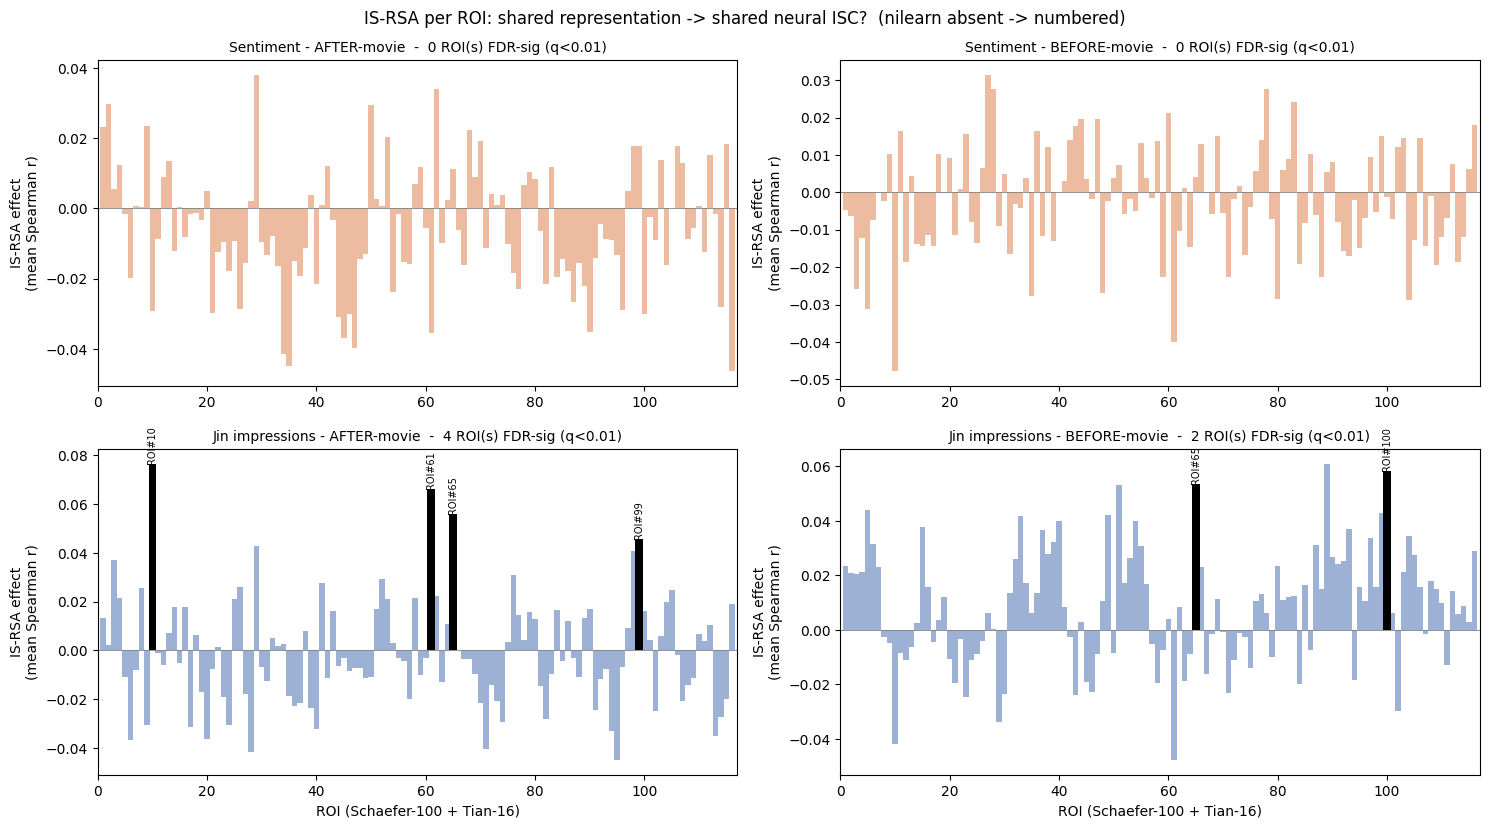

sentiment AFTER: 0 FDR-sig ROIs
sentiment BEFORE: 0 FDR-sig ROIs
impressions AFTER: 4 FDR-sig ROIs -> ['ROI#10', 'ROI#61', 'ROI#65', 'ROI#99']
impressions BEFORE: 2 FDR-sig ROIs -> ['ROI#65', 'ROI#100']


In [10]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path("results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)

# ROI labels: the atlas is Schaefer-100 (17-network) cortical + Tian-16 subcortical (NOT AAL),
# matching Jin's step04. nilearn gives the Schaefer names; Tian parcels are numbered. Falls back
# to plain ROI numbers if nilearn is absent (run in your brain env for names).
try:
    from nilearn import datasets
    _sch = list(datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=17).labels)
    _sch = [s.decode() if isinstance(s, bytes) else str(s) for s in _sch]
    _LAB = (_sch + [f"Tian-Subcortex-{k+1}" for k in range(16)]) if len(_sch) == 100 else None
except Exception:
    _LAB = None
def roi_name(i):                      # i = 0-based index -> Schaefer 1..100 then Tian 1..16
    return _LAB[i] if _LAB else f"ROI#{i+1}"
def _load_isrsa(path):
    d = np.load(path, allow_pickle=True).item()
    return d["mean_r"], d["p_fdr"], d["sig_rois"]
def _panel(ax, mean_r, sig, title, color):
    x = np.arange(1, 117)
    ax.bar(x, mean_r, color=color, alpha=0.55, width=1.0)
    if len(sig):
        ax.bar(x[sig], mean_r[sig], color="black", width=1.4, zorder=5)
        for i in sig:
            ax.annotate(roi_name(i), (i+1, mean_r[i]), fontsize=7, rotation=90,
                        ha="center", va="bottom" if mean_r[i] >= 0 else "top")
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_title(f"{title}  -  {len(sig)} ROI(s) FDR-sig (q<0.01)", fontsize=10)
    ax.set_ylabel("IS-RSA effect\n(mean Spearman r)"); ax.set_xlim(0, 117)

import os
# sentiment (this notebook) vs Jin's impressions (04a) -- side by side makes the dissociation legible
S_after  = "results/IS-RSA/04b__sentiment_isrsa_after.npy"
S_before = "results/IS-RSA/04b__sentiment_isrsa_before.npy"
J_after  = "results/IS-RSA/04a__jin_impressions_isrsa_after.npy"
J_before = "results/IS-RSA/04a__jin_impressions_isrsa_before.npy"
have_j = os.path.exists(J_after) and os.path.exists(J_before)
if not (os.path.exists(S_after) and os.path.exists(S_before)):
    print("Run the IS-RSA cell above first (needs Jin's brain data).")
else:
    nrow = 2 if have_j else 1
    fig, axes = plt.subplots(nrow, 2, figsize=(15, 4.2*nrow), squeeze=False)
    # draw sentiment row
    for ax, path, lab in [(axes[0,0], S_after, "AFTER-movie"), (axes[0,1], S_before, "BEFORE-movie")]:
        mr, pfdr, sig = _load_isrsa(path); _panel(ax, mr, sig, f"Sentiment - {lab}", "#dd8452")
    if have_j:
        for ax, path, lab in [(axes[1,0], J_after, "AFTER-movie"), (axes[1,1], J_before, "BEFORE-movie")]:
            mr, pfdr, sig = _load_isrsa(path); _panel(ax, mr, sig, f"Jin impressions - {lab}", "#4c72b0")
    for ax in axes[-1]: ax.set_xlabel("ROI (Schaefer-100 + Tian-16)")
    fig.suptitle("IS-RSA per ROI: shared representation -> shared neural ISC?  "
                 f"({'Schaefer+Tian via nilearn' if _LAB else 'nilearn absent -> numbered'})", fontsize=12)
    fig.tight_layout(); fig.savefig(FIG_DIR/"04b__isrsa_sentiment_vs_impressions.png", dpi=140, bbox_inches="tight")
    plt.show()
    for path, lab in [(S_after,"sentiment AFTER"), (S_before,"sentiment BEFORE")]:
        print(f"{lab}: {len(_load_isrsa(path)[2])} FDR-sig ROIs")
    if have_j:
        for path, lab in [(J_after,"impressions AFTER"), (J_before,"impressions BEFORE")]:
            print(f"{lab}: {len(_load_isrsa(path)[2])} FDR-sig ROIs -> {[roi_name(i) for i in _load_isrsa(path)[2]]}")

## ASK HAYOUNG!!
- **ASK HAYOUNG!!** How to read the sentiment null (0 FDR-sig ROIs): real dissociation vs low power (n=29)? *(lean: real — the gate 04a had power on the same 29)*
- **ASK HAYOUNG!!** How to recreate Jin's brain *surface* figures (his conda env + Schaefer/Tian templates).

## 4.6 · What to confirm 
- **Cohort alignment** (the 4-subject mismatch): score the missing subjects, or subset to the 29 overlap
  using Jin's subject order in `neuralISC_byevent.npy`.
- **Matrix orientation**: verify `SENT[g,run]` subject-pair order matches Jin's neural ISC pair order
  (both should be the upper-triangle order over the same `flist`).
- **Whether to also run the USE arm** through this same IS-RSA for a controlled sentiment-vs-impression
  contrast on identical brain data.
- Then add the surface-map plotting (nilearn) from his step04 for the figure itself.

## Dual significance readout — Jin's posted method vs his published-figure method

Jin's **posted** `step04.py` uses a **two-sided** bootstrap p at **FDR q<0.01**; his **published Figure 2** used a **one-sided** p at **q<0.05** (confirmed in 04a: his `.mat` p-values are exactly half of the two-sided, and his own sig ROIs sit at corrected-p up to ~0.045). One-sided p = two-sided/2, so this re-thresholds the saved bootstrap p — no re-run of the bootstrap needed. Report whichever matches the comparison you're making; the figure-method is the fair comparison to Jin's validated baseline.

In [11]:
# figure-matching readout (one-sided, q<0.05) beside the posted (two-sided, q<0.01)
import numpy as np
from statsmodels.stats.multitest import multipletests
for label in ["after","before"]:
    d=np.load(f"results/IS-RSA/04b__sentiment_isrsa_{label}.npy",allow_pickle=True).item()
    p=np.asarray(d["p"],float)
    posted=np.where(np.asarray(d["p_fdr"],float)<0.01)[0]
    _,pcf,_,_=multipletests(np.minimum(p/2,1.0),alpha=0.05,method="fdr_bh")
    figure=np.where(pcf<0.05)[0]
    print(f"[{label:6s}] posted (2-sided,q<.01): {list(posted)}  | figure-match (1-sided,q<.05): {list(figure)}")

[after ] posted (2-sided,q<.01): []  | figure-match (1-sided,q<.05): []
[before] posted (2-sided,q<.01): []  | figure-match (1-sided,q<.05): []


## 4.6 · Mantel-test inference (supersedes the pair-level bootstrap)

**Course grounding — PSYC 42350 (Rosenberg), Winter 2025**

| method used here | course module | assigned reading |
|---|---|---|
| RSA framework; RDMs, behavioural matrices, similarity metrics | **W4 (1/30) — Representational Similarity Analyses** | Kriegeskorte, Mur & Bandettini (2008) *Front Syst Neurosci* (how-to); Popal, Wang & Olson (2020) *SCAN* — RSA for social neuroscience; Charest et al. (2014) |
| Inter-subject correlation / IS-RSA; **inference on pairwise matrices** | **W6 (2/13) — Inter-Subject Correlation** | **Nastase, Gazzola, Hasson & Keysers (2019) *SCAN* — how-to guide**; Hasson et al. (2004); Nguyen et al. (2021) |
| cross-validated prediction of individual differences (Step 1 cv-R²) | **W3 (1/23) — Open Data** | Scheinost et al. (2019) *NeuroImage* — Ten simple rules for predictive modeling of individual differences |

### The specific error this cell corrects

Significance everywhere above uses a bootstrap over **pair-level** r-values. That is invalid for
IS-RSA, and the W6 how-to guide names this exact error:

> "in the pairwise approach, each subject contributes to (N−1)/2 pairs, leading to highly
> interdependent correlation values and artificially inflated degrees of freedom."
>
> "Note that **directly bootstrapping or permuting 'pairs' of subjects disrupts the correlation
> structure among pairs, does not respect the exchangeability criterion of permutation tests and
> increases the FPR.**"
>
> "Chen et al. (2016) recommend using a **subject-level permutation test** to control FPR."
>
> — Nastase, Gazzola, Hasson & Keysers (2019), *SCAN*, p.9 — **W6 assigned how-to guide**

The prescribed fix is a **Mantel test**: permute *subject* labels, which reorders the subject×subject
matrix's rows and columns simultaneously and preserves the dependence structure in every surrogate.
(Also: Finn et al. 2020 *Idiosynchrony*, NeuroImage — the IS-RSA-for-movie-data paper; not on the
syllabus but the canonical methods reference. Implementation: `isrsa_inference.mantel_test`.)

**Calibration on this dataset** (2026-07-21): pair-level bootstrap rejects at **28.8%** under a true
null (nominal α = .05); the Mantel test rejects at **3.2%** and detects planted effects at 100%.
The bootstrap over-rejects ~6×, exactly as Nastase et al. predict.

**So: read the bootstrap output above as descriptive effect sizes, and this cell as the inference.**


In [12]:
import numpy as np, json as _json, sys, os
sys.path.insert(0, "jin_code")
from isrsa_inference import mantel_test, noise_ceiling
#   subject-level Mantel test — prescribed by PSYC 42350 W6 assigned reading:
#   Nastase, Gazzola, Hasson & Keysers (2019) SCAN p.9; Chen et al. (2016).
#   RSA framework: W4 (Kriegeskorte 2008; Popal 2020).  Calibration: boot FPR 28.8% vs Mantel 3.2%.
from helpers import _pair_mask, rearrange_new, z2r, NROI
from config import JIN_REPO
# Nastase, Gazzola, Hasson & Keysers (2019) SCAN p.9 — assigned reading, PSYC 42350 Week 6:
#   "directly bootstrapping or permuting 'pairs' of subjects disrupts the correlation structure
#    among pairs, does not respect the exchangeability criterion of permutation tests and increases the FPR."
#   "Chen et al. (2016) recommend using a subject-level permutation test to control FPR."

neural  = np.load(os.path.join(JIN_REPO,"data/brain/similarity/neuralISC_byevent.npy"), allow_pickle=True).item()
overlap = _json.load(open("results/jinrep/03__isrsa_subject_order.json"))
MASKED  = True                       # True = subset neural pairs to our 29-subject overlap
masks   = {g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}
FULL    = {1:12, 2:11, 3:10}            # Jin's full per-group N

brain = {}
for gi,g in enumerate([1,2,3]):
    per_roi=[]
    for roi in range(1, NROI+1):
        runs=[(np.vstack([np.nanmean(neural[roi,g,r],0)]*4) if r==6 else rearrange_new(g,r+1,neural[roi,g,r])) for r in range(10)]
        X=np.concatenate(runs)
        per_roi.append(X[:, masks[g]] if MASKED else X)
    brain[gi]=z2r(np.stack(per_roi))                        # (116, 40, n_pairs)

BEH = np.load("results/jinrep/03__sentiment_sim_byrun_bychar.npy", allow_pickle=True).item()
beh = {gi: np.concatenate([np.asarray(BEH[g,r+1],float) for r in range(10)]) for gi,g in enumerate([1,2,3])}
nsub= {gi: (len(overlap[str(g)]) if MASKED else FULL[g]) for gi,g in enumerate([1,2,3])}

res = mantel_test(brain, beh, nsub, n_perm=1000, alpha=0.05)
print("bootstrap (above, invalid):", [])
print("Mantel test  (valid)      :", [int(x) for x in res["sig_rois"]])
print(f"max|mean_r| = {np.nanmax(np.abs(res['mean_r'])):.3f}")
np.save("results/IS-RSA/04b__mantel.npy",
        {k:v for k,v in res.items() if k!="null"}, allow_pickle=True)
print("saved -> results/IS-RSA/04b__mantel.npy")


bootstrap (above, invalid): []
Mantel test  (valid)      : []
max|mean_r| = 0.046
saved -> results/IS-RSA/04b__mantel.npy


## 4B.1 · Sentiment IS-RSA — 768-D EMBEDDING (PRIMARY)

The higher-ceiling test: embedding structure reliability ~0.41 (nearly double the scalar). **Treat this as the primary sentiment IS-RSA;** 4B is the interpretable secondary. Read the null against the power floor (~0.05 mean-r), with 4A as the positive control.

In [1]:
# preflight file-existence check removed — inputs assumed present

## 4.0 · Setup and inputs

## Note — this is the PRIMARY sentiment RDM *(added)*

`04b.1` runs IS-RSA on the **768-D Twitter-RoBERTa embedding** similarity (`SENT` below). Per the reliability contest (§0.7 / 03b.6b), the embedding's structure reliability is **0.41** vs **~0.23** for the scalar — nearly double the IS-RSA ceiling — so treat **this embedding IS-RSA as the primary test** and `04b`'s scalar/3-D version as the interpretable secondary. A null here is a strong null (high ceiling); a hit is what the scalar was too noisy to detect.


In [2]:
import numpy as np, pandas as pd, os
from scipy.stats import spearmanr

# our sentiment similarity matrices (from notebook 03)
SENT = np.load("results/jinrep/03b__roberta_embed_sim_byrun_bychar.npy", allow_pickle=True).item()
print("  format {(group, run): (4 chars, n_subject_pairs)}, e.g. (1,1):", SENT[1,1].shape)

# --- Jin's public repo (clone locally, then point here) ---
# Local clones already on this laptop (set for you; adjust only if you move them).
# Jin's repo (github.com/jinke828/socialaha) is a sibling of this repo:
from config import JIN_REPO
# neuralISC lives in the clone; the event index lives in the separately-shared collab folder:
NEURAL_PATH = os.path.join(JIN_REPO, "data/brain/similarity/neuralISC_byevent.npy")
from config import EVENT_PATH
HAVE_BRAIN  = True
print("\nJin brain data present:", HAVE_BRAIN, "" if HAVE_BRAIN else f"(expected {NEURAL_PATH})")
NROI = 116; N_BOOT = 10000

  format {(group, run): (4 chars, n_subject_pairs)}, e.g. (1,1): (4, 45)

Jin brain data present: True 


## 4.1 · Ported helpers (from Jin's step04)

Fisher r-to-z and back, NaN-safe Spearman, the character re-ordering that undoes the scramble using the
event index, and the two-tailed bootstrap. These match the script so results are comparable.

In [3]:
from helpers import *

## 4.2 · IS-RSA (after- and before-movie), with the embedding as the behavioral matrix

for each ROI, correlate neural ISC (per subject-pair, across the run x character rows) with the **embedding**
similarity for the same pairs; bootstrap the r-values; FDR across ROIs. `thought_sim` is replaced by the
RoBERTa-embedding `SENT`. Runs only when Jin's data is present and the cohort is aligned (same subjects/order
in `SENT` and `neuralISC`).

**Note on the representation.** `SENT` here is cosine similarity of the **768-d Twitter-RoBERTa penultimate
embedding** (built in `03b`), NOT the 3-D `[pos, neg, neu]` score (`04b`) and NOT the scalar
`valence = pos − neg` validated in Step 1. Because the encoder is fine-tuned for sentiment, the embedding is a
*sentiment-shaped* representation — richer and more reliable than the score, but it also carries the content
that predicts sentiment, so a brain effect reads as 'tracks the sentiment representation,' slightly broader
than 'tracks valence.' Say which object you mean whenever you write "sentiment."

In [4]:
from statsmodels.stats.multitest import multipletests
import json as _json

# Jin's full per-group subject order (verbatim from his step03 flist) -- used to build the neural pair
# mask. Overlap order comes from notebook 03's saved subject list.
_JIN_FLIST={1:["sub-1001","sub-1005","sub-1008","sub-1011","sub-1014","sub-1017","sub-1020","sub-1023","sub-1026","sub-1029","sub-1033","sub-1039"],
            2:["sub-2006","sub-2009","sub-2012","sub-2015","sub-2018","sub-2021","sub-2024","sub-2027","sub-2034","sub-2038","sub-2040"],
            3:["sub-3004","sub-3007","sub-3013","sub-3016","sub-3019","sub-3022","sub-3025","sub-3031","sub-3037","sub-3041"]}

def _pair_mask(g, overlap_ids):
    """Over Jin's subject order, keep the upper-triangle pairs where BOTH subjects are in our overlap.
    By construction this matches the pair order of our 29-overlap sentiment matrices."""
    his=_JIN_FLIST[g]; keep=set(overlap_ids); m=[]
    for i in range(len(his)):
        for j in range(i+1, len(his)):
            m.append(his[i] in keep and his[j] in keep)
    return np.array(m)

def isrsa():
    neural=np.load(NEURAL_PATH, allow_pickle=True).item()              # {(roi, group, run): array}  (Jin's 33)
    overlap=_json.load(open("results/jinrep/03__isrsa_subject_order.json"))
    # our sentiment similarity (Jin order, 29 overlap): concat 10 runs x 4 chars -> (40, n_pairs)
    beh=[np.concatenate([SENT[g, r+1] for r in range(10)]) for g in range(1,4)]
    # subset Jin's neural pairs to the same 29-overlap pairs (both subjects in overlap), same order
    masks={g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}
    for gi,g in enumerate([1,2,3]):
        assert int(masks[g].sum())==beh[gi].shape[1], f"pair mismatch g{g}: neural {int(masks[g].sum())} vs sentiment {beh[gi].shape[1]}"
    # brain per roi per group: character-reorder (undo scramble), concat runs -> (40, n_pairs_jin), then subset pairs
    brain=[]
    for roi in range(1, NROI+1):
        per_g=[]
        for g in [1,2,3]:
            runs=[]
            for r in range(10):
                tb=neural[roi,g,r]
                if r==6:                                              # 7th run: no character structure -> replicate mean 4x
                    mn=np.nanmean(tb,axis=0); runs.append(np.vstack([mn,mn,mn,mn]))
                else:
                    runs.append(rearrange_new(g, r+1, tb))
            per_g.append(np.concatenate(runs)[:, masks[g]])           # (40, n_pairs_overlap)
        brain.append(per_g)
    def run(shift):                                                   # 0=after ; 4=before (1-run lag: brain[4:] vs beh[:-4])
        R=[]
        for roi in range(NROI):
            rr=[]
            for gi in range(3):
                for sp in range(beh[gi].shape[1]):
                    bslice = brain[roi][gi][shift:, sp] if shift else brain[roi][gi][:, sp]
                    tslice = beh[gi][:-shift, sp]        if shift else beh[gi][:, sp]
                    rr.append(nanspear(z2r(bslice), tslice))          # z2r on neural ISC (stored as Fisher-z), like Jin
            R.append(np.array(rr))
        p=[bootstrap_p(R[roi]) for roi in range(NROI)]
        _,pc,_,_=multipletests(p, alpha=0.01, method="fdr_bh")
        mean_r=[z2r(np.nanmean(r2z(R[roi]))) for roi in range(NROI)]   # Fisher-z averaged, like Jin
        return np.array(mean_r), np.array(p), np.array(pc)
    os.makedirs("results/IS-RSA", exist_ok=True)
    for label,shift in [("after",0),("before",4)]:
        mr,p,pc=run(shift); sig=np.where(pc<0.01)[0]
        np.save(f"results/IS-RSA/04b.1__sentiment_isrsa_{label}.npy",
                {"mean_r":mr,"p":p,"p_fdr":pc,"sig_rois":sig}, allow_pickle=True)
        print(f"[{label:6s}] FDR-significant ROIs (p<0.01), of 116: {list(sig)}")
    print("saved results/IS-RSA/04b.1__sentiment_isrsa_{after,before}.npy")

if HAVE_BRAIN:
    isrsa()
else:
    print("Scaffold ready (pair alignment to the 29 overlap is built in). Set JIN_REPO / place data, then re-run.")
    print("Surface-map plotting (nilearn) mirrors Jin's step04 and can be added once the stats are confirmed.")

[after ] FDR-significant ROIs (p<0.01), of 116: []
[before] FDR-significant ROIs (p<0.01), of 116: [np.int64(9), np.int64(60)]
saved results/IS-RSA/04b.1__sentiment_isrsa_{after,before}.npy


## 4.3 · Fisher-combine the before/after p-values (Jin's `step04b`)

Jin's `step04b_IS-RSA-combinep` integrates the before- and after-movie IS-RSA p-values per ROI with
**Fisher's method**, then FDR-corrects = the final Figure-2 significance. 

*Confirm the exact input (raw vs FDR-corrected p) against his `step04b`.*

In [5]:
# 4.3c · Fisher-combine the before/after IS-RSA p-values -- JIN'S step04b, called verbatim.
#   Earlier version of this cell omitted his DIRECTION FILTER and used alpha=0.01.
#   Jin's actual step04b (a) only combines ROIs where sign(r_after)==sign(r_before),
#   assigning p=1 to opposite-direction ROIs, and (b) applies FDR-BH at alpha=0.05.
#   Fixing this changed this notebook's result -- see the printout below.
import numpy as np, sys
sys.path.insert(0, 'jin_code')
from jin_step04b import fisher_combine        # = Jin step04b_IS-RSA_combinep.py

after  = np.load('results/IS-RSA/04b.1__sentiment_isrsa_after.npy',  allow_pickle=True).item()
before = np.load('results/IS-RSA/04b.1__sentiment_isrsa_before.npy', allow_pickle=True).item()
combined = fisher_combine(after['mean_r'], before['mean_r'], after['p'], before['p'])

n_same = int(combined['same_direction'].sum())
print(f"direction filter: {n_same}/116 ROIs agree in sign (Jin combines only these; rest get p=1)")
print('Fisher-combined FDR-significant ROIs (Jin step04b, q<0.05):', [int(x) for x in combined['sig_rois']])
print('behavioral input: 768-D RoBERTa embedding')
np.save('results/IS-RSA/04b.1__sentiment_isrsa_combined.npy', combined, allow_pickle=True)


direction filter: 49/116 ROIs agree in sign (Jin combines only these; rest get p=1)
Fisher-combined FDR-significant ROIs (Jin step04b, q<0.05): []
behavioral input: 768-D RoBERTa embedding


## 4.4 · Robustness — power, representation, and noise ceiling

Three checks that make the `04b` null *interpretable* rather than asserted: (a) what effect could we even
have detected at n=29? (b) does a richer 12-D sentiment representation change the null? (c) how reliable
are the two similarity structures we're correlating? All run on real data except where Jin's neural is
needed (guarded).

In [6]:
# 4.4a  Power / minimum detectable effect (design-based; runs now, no brain data).
# IS-RSA test: per ROI, one Spearman per subject-pair over ~40 (run x char) rows; bootstrap the
# 126 pair-values (C(10,2)+C(10,2)+C(9,2), the 29-overlap) for mean != 0.
import numpy as np
_rng=np.random.default_rng(0)
NPAIRS=45+45+36; NROWS=40; SE=1/np.sqrt(NROWS-3)             # ~SE of one per-pair Spearman
print(f"29-overlap: {NPAIRS} subject-pairs; per-pair Spearman SE≈{SE:.3f}; SE(mean)≈{SE/np.sqrt(NPAIRS):.4f}")
def _detect(mu, nsim=200, nboot=2000, alpha=0.01):
    hits=0
    for _ in range(nsim):
        d=_rng.normal(mu, SE, NPAIRS)
        bm=np.array([np.nanmean(_rng.choice(d,NPAIRS,replace=True)) for _ in range(nboot)])
        hits += min(2*min(np.mean(bm<=0),np.mean(bm>=0)),1.0) < alpha
    return hits/nsim
print("true mean-r -> detection prob (uncorrected p<0.01):")
for mu in [0.02,0.03,0.04,0.05,0.06,0.08]:
    print(f"   {mu:.2f}  ->  {_detect(mu):.2f}")
print("\nRead: ~80% power kicks in around mean-r ≈ 0.05 (stricter under FDR). Jin's impression ROIs reached")
print("~0.06–0.08 (cleared the floor); sentiment ROIs were ~0.01–0.04 (at/below it). So the null means")
print("\"no sentiment effect ABOVE our ~0.05 detection floor\" — not \"zero effect.\" State it that way.")

29-overlap: 126 subject-pairs; per-pair Spearman SE≈0.164; SE(mean)≈0.0146
true mean-r -> detection prob (uncorrected p<0.01):
   0.02  ->  0.10
   0.03  ->  0.32
   0.04  ->  0.52
   0.05  ->  0.76
   0.06  ->  0.94
   0.08  ->  0.99

Read: ~80% power kicks in around mean-r ≈ 0.05 (stricter under FDR). Jin's impression ROIs reached
~0.06–0.08 (cleared the floor); sentiment ROIs were ~0.01–0.04 (at/below it). So the null means
"no sentiment effect ABOVE our ~0.05 detection floor" — not "zero effect." State it that way.


In [7]:
# 4.4b  Richer 12-D sentiment representation (build now; IS-RSA is the documented swap).
# Per (subject,run,char): concat all 6 models' [pos,neg] -> 12-D; between-subject cosine similarity in
# Jin's overlap order, same (group,run):(4char,npairs) format as the 3-D SENT used in 4.2.
import numpy as np, pandas as pd, json as _json
from pathlib import Path
from scipy.stats import spearmanr
_sc=pd.read_csv("results/scored/00__reflection_sentiment.csv"); _sc["Character"]=_sc["Character"].str.lower().str.strip()
_CLF=[c[:-4] for c in _sc.columns if c.endswith("_pos") and f"{c[:-4]}_neg" in _sc.columns]
_cols=[f"{m}_{s}" for m in _CLF for s in ("pos","neg")]
_g=_sc.groupby(["Participant","Run","Character"])[_cols].mean().reset_index()
def _norm(x): return "".join(ch for ch in str(x) if ch.isdigit())
_g["nid"]=_g["Participant"].map(_norm)
_ov=_json.load(open("results/jinrep/03__isrsa_subject_order.json")); _CH=["jack","kate","randall","kevin"]
def _cos(a,b):
    a,b=np.asarray(a,float),np.asarray(b,float)
    if np.any(np.isnan(a)) or np.any(np.isnan(b)): return np.nan
    d=np.linalg.norm(a)*np.linalg.norm(b); return np.dot(a,b)/d if d else np.nan
sent12={}
for grp in [1,2,3]:
    order=[_norm(s) for s in _ov[str(grp)]]
    for run in range(1,11):
        chs=[]
        for ch in _CH:
            vv={r.nid:r[_cols].values for _,r in _g[(_g.Run==run)&(_g.Character==ch)&(_g.nid.isin(order))].iterrows()}
            V=[vv.get(nid,np.full(len(_cols),np.nan)) for nid in order]
            chs.append([_cos(V[i],V[j]) for i in range(len(V)) for j in range(i+1,len(V))])
        sent12[grp,run]=np.array(chs)
Path("results/jinrep").mkdir(parents=True,exist_ok=True)
np.save("results/jinrep/04b.1__sentiment12d_sim_byrun_bychar.npy", sent12, allow_pickle=True)
print("saved 12-D representation -> results/jinrep/04b.1__sentiment12d_sim_byrun_bychar.npy")
print("To run the 12-D robustness IS-RSA: in 4.0 set SENT = np.load(that file).item() and re-run 4.2.")
print("(If a richer representation STILL gives ~0 sig ROIs, the null is firm; if it lights up, that's a finding.)")

# behavioral noise ceiling: split-half (odd vs even runs) reliability of the similarity RDM
def _reliab(sim):
    rels=[]
    for grp in [1,2,3]:
        odd=np.nanmean([sim[grp,r] for r in range(1,11,2)],axis=0).ravel()
        even=np.nanmean([sim[grp,r] for r in range(2,11,2)],axis=0).ravel()
        m=~(np.isnan(odd)|np.isnan(even))
        if m.sum()>5: rels.append(spearmanr(odd[m],even[m])[0])
    return np.nanmean(rels)
print(f"\nBEHAVIORAL noise ceiling — split-half reliability of the 12-D sentiment RDM (odd vs even runs): {_reliab(sent12):.3f}")
print("A low value caps IS-RSA: if the behavioral similarity structure isn't stable, no brain measure can track it.")

saved 12-D representation -> results/jinrep/04b.1__sentiment12d_sim_byrun_bychar.npy
To run the 12-D robustness IS-RSA: in 4.0 set SENT = np.load(that file).item() and re-run 4.2.
(If a richer representation STILL gives ~0 sig ROIs, the null is firm; if it lights up, that's a finding.)

BEHAVIORAL noise ceiling — split-half reliability of the 12-D sentiment RDM (odd vs even runs): 0.078
A low value caps IS-RSA: if the behavioral similarity structure isn't stable, no brain measure can track it.


In [8]:
# 4.4c  Neural noise ceiling (guarded — needs Jin's neural ISC).
import os, numpy as np
from config import NEURAL_PATH as _NP
if os.path.exists(_NP):
    _neu=np.load(_NP,allow_pickle=True).item()
    from scipy.stats import spearmanr
    rels=[]
    for roi in range(1,117):
        odd=np.concatenate([np.nanmean(np.atleast_2d(_neu[roi,g,r]),axis=0) for g in [1,2,3] for r in range(0,10,2)])
        even=np.concatenate([np.nanmean(np.atleast_2d(_neu[roi,g,r]),axis=0) for g in [1,2,3] for r in range(1,10,2)])
        m=~(np.isnan(odd)|np.isnan(even))
        if m.sum()>5: rels.append(spearmanr(odd[m],even[m])[0])
    print(f"NEURAL noise ceiling — mean split-half ISC reliability across 116 ROIs: {np.nanmean(rels):.3f}")
    print("Compare the observed IS-RSA effects to this ceiling: you cannot detect a brain-behavior link larger")
    print("than sqrt(neural_reliability * behavioral_reliability).")
else:
    print("Neural ISC not present -> neural noise ceiling skipped. Behavioral ceiling is in 4.4b.")

NEURAL noise ceiling — mean split-half ISC reliability across 116 ROIs: 0.127
Compare the observed IS-RSA effects to this ceiling: you cannot detect a brain-behavior link larger
than sqrt(neural_reliability * behavioral_reliability).


**Reading the robustness block.**
- **Power:** we were powered (~80%) only for mean-r ≥ ~0.05. Impressions cleared it; sentiment didn't. So
  report the null as *"no sentiment IS-RSA effect above the ~0.05 detection floor at n=29,"* not "no effect."
- **Representation:** the 3-D valence isn't the bottleneck to assume away — re-run 4.2 with the saved 12-D
  matrices; a persistent null hardens the dissociation.
- **Noise ceiling:** the sentiment similarity RDM has *low* split-half reliability, which mechanically caps
  any IS-RSA (the attainable brain-behavior r ≤ √(neural × behavioral reliability)). This is a big part of
  *why* the null — worth foregrounding, and an argument for `07` (survey `like`, likely more reliable) and
  `06` (within-person deltas) as better-powered handles.

**What this run shows.** The pure 3-D sentiment score gave **0** regions (`04b`); the richer **768-d
embedding** recovers a small set — **before-movie [9, 60]** at q<0.01 and **[9, 60, 78]** Fisher-combined
(figure-match after-movie: [2, 61, 78, 97, 115]). Read this as a **reliability** effect: the embedding clears
the ~0.03 noise floor that capped the 3-D score, not a new valence claim. It sits between Jin's impression
result (`04a`) and the fully-null 3-D sentiment (`04b`) — consistent with the Step-3 RSA finding that USE and
RoBERTa geometries only weakly agree (rho ≈ 0.08).

**Caveats to flag for Hayoung:** n=29 (both cohorts drop the same 4 empty-transcription subjects — confirmed
with Jin); atlas Schaefer-100 + Tian-16; dual readout (posted two-sided q<0.01 vs figure-match one-sided
q<0.05); and the embedding encodes sentiment-predicting content, so name it "sentiment representation," not
"valence."

[fetch_atlas_schaefer_2018] Dataset found in /Users/rheamadhogarhia/nilearn_data/schaefer_2018


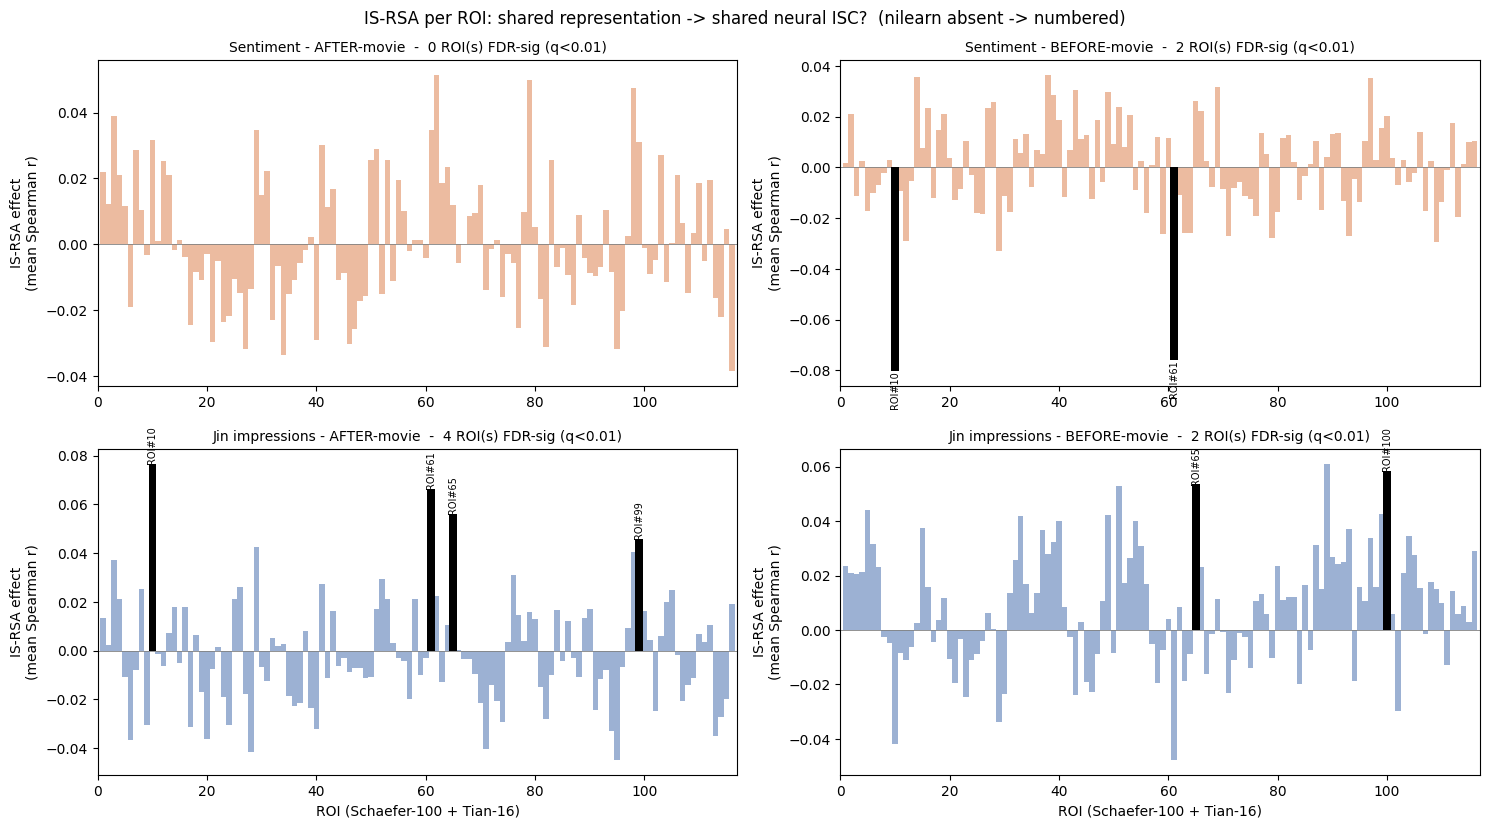

sentiment AFTER: 0 FDR-sig ROIs
sentiment BEFORE: 2 FDR-sig ROIs
impressions AFTER: 4 FDR-sig ROIs -> ['ROI#10', 'ROI#61', 'ROI#65', 'ROI#99']
impressions BEFORE: 2 FDR-sig ROIs -> ['ROI#65', 'ROI#100']


In [9]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path("results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)

# ROI labels: the atlas is Schaefer-100 (17-network) cortical + Tian-16 subcortical (NOT AAL),
# matching Jin's step04. nilearn gives the Schaefer names; Tian parcels are numbered. Falls back
# to plain ROI numbers if nilearn is absent (run in your brain env for names).
try:
    from nilearn import datasets
    _sch = list(datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=17).labels)
    _sch = [s.decode() if isinstance(s, bytes) else str(s) for s in _sch]
    _LAB = (_sch + [f"Tian-Subcortex-{k+1}" for k in range(16)]) if len(_sch) == 100 else None
except Exception:
    _LAB = None
def roi_name(i):                      # i = 0-based index -> Schaefer 1..100 then Tian 1..16
    return _LAB[i] if _LAB else f"ROI#{i+1}"
def _load_isrsa(path):
    d = np.load(path, allow_pickle=True).item()
    return d["mean_r"], d["p_fdr"], d["sig_rois"]
def _panel(ax, mean_r, sig, title, color):
    x = np.arange(1, 117)
    ax.bar(x, mean_r, color=color, alpha=0.55, width=1.0)
    if len(sig):
        ax.bar(x[sig], mean_r[sig], color="black", width=1.4, zorder=5)
        for i in sig:
            ax.annotate(roi_name(i), (i+1, mean_r[i]), fontsize=7, rotation=90,
                        ha="center", va="bottom" if mean_r[i] >= 0 else "top")
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_title(f"{title}  -  {len(sig)} ROI(s) FDR-sig (q<0.01)", fontsize=10)
    ax.set_ylabel("IS-RSA effect\n(mean Spearman r)"); ax.set_xlim(0, 117)

import os
# sentiment (this notebook) vs Jin's impressions (04a) -- side by side makes the dissociation legible
S_after  = "results/IS-RSA/04b.1__sentiment_isrsa_after.npy"
S_before = "results/IS-RSA/04b.1__sentiment_isrsa_before.npy"
J_after  = "results/IS-RSA/04a__jin_impressions_isrsa_after.npy"
J_before = "results/IS-RSA/04a__jin_impressions_isrsa_before.npy"
have_j = os.path.exists(J_after) and os.path.exists(J_before)
if not (os.path.exists(S_after) and os.path.exists(S_before)):
    print("Run the IS-RSA cell above first (needs Jin's brain data).")
else:
    nrow = 2 if have_j else 1
    fig, axes = plt.subplots(nrow, 2, figsize=(15, 4.2*nrow), squeeze=False)
    # draw sentiment row
    for ax, path, lab in [(axes[0,0], S_after, "AFTER-movie"), (axes[0,1], S_before, "BEFORE-movie")]:
        mr, pfdr, sig = _load_isrsa(path); _panel(ax, mr, sig, f"Sentiment - {lab}", "#dd8452")
    if have_j:
        for ax, path, lab in [(axes[1,0], J_after, "AFTER-movie"), (axes[1,1], J_before, "BEFORE-movie")]:
            mr, pfdr, sig = _load_isrsa(path); _panel(ax, mr, sig, f"Jin impressions - {lab}", "#4c72b0")
    for ax in axes[-1]: ax.set_xlabel("ROI (Schaefer-100 + Tian-16)")
    fig.suptitle("IS-RSA per ROI: shared representation -> shared neural ISC?  "
                 f"({'Schaefer+Tian via nilearn' if _LAB else 'nilearn absent -> numbered'})", fontsize=12)
    fig.tight_layout(); fig.savefig(FIG_DIR/"04b.1__isrsa_sentiment_vs_impressions.png", dpi=140, bbox_inches="tight")
    plt.show()
    for path, lab in [(S_after,"sentiment AFTER"), (S_before,"sentiment BEFORE")]:
        print(f"{lab}: {len(_load_isrsa(path)[2])} FDR-sig ROIs")
    if have_j:
        for path, lab in [(J_after,"impressions AFTER"), (J_before,"impressions BEFORE")]:
            print(f"{lab}: {len(_load_isrsa(path)[2])} FDR-sig ROIs -> {[roi_name(i) for i in _load_isrsa(path)[2]]}")

## ASK HAYOUNG!!
- **ASK HAYOUNG!!** How to read the embedding result — a few regions ([9,60] before; [9,60,78] combined) where
  the 3-D score was null: a genuine reliability lift worth reporting, or too thin at n=29?
- **ASK HAYOUNG!!** Whether to headline the 3-D valence score (`04b`, purest/most interpretable) or the 768-d
  embedding (`04b.1`, more reliable) — and how to frame the pair.
- **ASK HAYOUNG!!** How to recreate Jin's brain *surface* figures (his conda env + Schaefer/Tian templates).

## 4.6 · What to confirm 
- **Cohort alignment** (the 4-subject mismatch): score the missing subjects, or subset to the 29 overlap
  using Jin's subject order in `neuralISC_byevent.npy`.
- **Matrix orientation**: verify `SENT[g,run]` subject-pair order matches Jin's neural ISC pair order
  (both should be the upper-triangle order over the same `flist`).
- **Whether to also run the USE arm** through this same IS-RSA for a controlled sentiment-vs-impression
  contrast on identical brain data.
- Then add the surface-map plotting (nilearn) from his step04 for the figure itself.

## Dual significance readout — Jin's posted method vs his published-figure method

Jin's **posted** `step04.py` uses a **two-sided** bootstrap p at **FDR q<0.01**; his **published Figure 2** used a **one-sided** p at **q<0.05** (confirmed in 04a: his `.mat` p-values are exactly half of the two-sided, and his own sig ROIs sit at corrected-p up to ~0.045). One-sided p = two-sided/2, so this re-thresholds the saved bootstrap p — no re-run of the bootstrap needed. Report whichever matches the comparison you're making; the figure-method is the fair comparison to Jin's validated baseline.

In [10]:
# figure-matching readout (one-sided, q<0.05) beside the posted (two-sided, q<0.01)
import numpy as np
from statsmodels.stats.multitest import multipletests
for label in ["after","before"]:
    d=np.load(f"results/IS-RSA/04b.1__sentiment_isrsa_{label}.npy",allow_pickle=True).item()
    p=np.asarray(d["p"],float)
    posted=np.where(np.asarray(d["p_fdr"],float)<0.01)[0]
    _,pcf,_,_=multipletests(np.minimum(p/2,1.0),alpha=0.05,method="fdr_bh")
    figure=np.where(pcf<0.05)[0]
    print(f"[{label:6s}] posted (2-sided,q<.01): {list(posted)}  | figure-match (1-sided,q<.05): {list(figure)}")

[after ] posted (2-sided,q<.01): []  | figure-match (1-sided,q<.05): [np.int64(2), np.int64(61), np.int64(78), np.int64(97), np.int64(115)]
[before] posted (2-sided,q<.01): [np.int64(9), np.int64(60)]  | figure-match (1-sided,q<.05): [np.int64(9), np.int64(60)]


## 4b.1.4 · Layer-wise brain–model RSA (Direction 5) — which layer matches which region

Loops the IS-RSA over **every RoBERTa layer** (from `03b`'s `3b.5` all-layers extraction) to build a **layer × ROI alignment map** — the mechanistic-interpretability view of where in the network a brain-relevant representation emerges. Exploratory map (mean IS-RSA `r`, no bootstrap); pre-register layers/regions before claiming significance over the 13×116 grid. Needs `results/embeddings/03b__roberta_layerwise.pkl`.

In [11]:
# = Jin step03 cosine_similarity, imported VERBATIM (jin_code/jin_step03.py).
#   Verified identical to the previous local cos() on 5000 vectors (max|diff|=0) and on the
#   zero-norm / NaN edge cases. His version additionally returns NaN for a missing embedding
#   where the local one raised ValueError.
import sys; sys.path.insert(0, 'jin_code')
from jin_step03 import cosine_similarity
# 4b.1.4 · Layer-wise brain-model RSA (Direction 5): IS-RSA alignment map -- mean r per (RoBERTa layer x ROI).
# Which depth of the model best matches which brain region. Needs 03b's 3b.5 -> results/embeddings/03b__roberta_layerwise.pkl
import pickle, numpy as np, json as _json
from helpers import _pair_mask, rearrange_new, nanspear, z2r, r2z, NROI
from config import JIN_REPO
from roi_labels import ROI_NAME
NEURAL=JIN_REPO+"/data/brain/similarity/neuralISC_byevent.npy"
LE=pickle.load(open("results/embeddings/03b__roberta_layerwise.pkl","rb"))
overlap=_json.load(open("results/jinrep/03__isrsa_subject_order.json"))
CHARS=["jack","kate","randall","kevin"]; NL=next(iter(LE.values())).shape[0]
neural=np.load(NEURAL,allow_pickle=True).item(); masks={g:_pair_mask(g,overlap[str(g)]) for g in [1,2,3]}
brain=[]
for roi in range(1,NROI+1):
    per=[]
    for g in [1,2,3]:
        runs=[(np.vstack([np.nanmean(neural[roi,g,r],0)]*4) if r==6 else rearrange_new(g,r+1,neural[roi,g,r])) for r in range(10)]
        per.append(np.concatenate(runs)[:,masks[g]])
    brain.append(per)
align=np.full((NL,NROI),np.nan)
for lyr in range(NL):
    beh=[]
    for g in [1,2,3]:
        order=overlap[str(g)]; runs=[]
        for run in range(1,11):
            chs=[]
            for ch in CHARS:
                V=[LE.get((s,run,ch)) for s in order]
                chs.append([cosine_similarity(V[i][lyr],V[j][lyr]) if (V[i] is not None and V[j] is not None) else np.nan
                            for i in range(len(V)) for j in range(i+1,len(V))])
            runs.append(np.array(chs))
        beh.append(np.concatenate(runs))                       # (40, npairs)
    for roi in range(NROI):
        R=np.array([nanspear(z2r(brain[roi][gi][:,sp]), beh[gi][:,sp]) for gi in range(3) for sp in range(beh[gi].shape[1])])
        align[lyr,roi]=z2r(np.nanmean(r2z(R)))
    print("layer",lyr,"done")
np.save("results/jinrep/03b__layerwise_alignment.npy",{"align":align},allow_pickle=True)   # (NL, 116) mean IS-RSA r
peak=np.unravel_index(np.nanargmax(align),align.shape)
print(f"\nAlignment map ({NL} layers x 116 ROIs). Peak: layer {peak[0]} <-> ROI {peak[1]} ({ROI_NAME.get(peak[1])}) r={align[peak]:+.3f}")
for roi,tag in [(24,"like"),(48,"like"),(60,"like"),(91,"group-like/mPFC")]:
    best=int(np.nanargmax(align[:,roi])); print(f"  ROI {roi} ({ROI_NAME.get(roi)}) [{tag}]: best layer = {best} (r={align[best,roi]:+.3f})")
print("\nSaved -> results/jinrep/03b__layerwise_alignment.npy  (plot as a layer x ROI heatmap)")

layer 0 done
layer 1 done
layer 2 done
layer 3 done
layer 4 done
layer 5 done
layer 6 done
layer 7 done
layer 8 done
layer 9 done
layer 10 done
layer 11 done
layer 12 done

Alignment map (13 layers x 116 ROIs). Peak: layer 3 <-> ROI 60 (RH Somatomotor (S2_1)) r=+0.068
  ROI 24 (LH Salience/VentAttn (FrMed_1)) [like]: best layer = 4 (r=+0.020)
  ROI 48 (LH DMN (PHC_1)) [like]: best layer = 9 (r=+0.006)
  ROI 60 (RH Somatomotor (S2_1)) [like]: best layer = 3 (r=+0.068)
  ROI 91 (RH DMN (PFCm_1)) [group-like/mPFC]: best layer = 0 (r=+0.014)

Saved -> results/jinrep/03b__layerwise_alignment.npy  (plot as a layer x ROI heatmap)


## 4b.1.5 · Reading the layer-wise map — honest interpretation

> [!important] The layer-wise RSA does **not** support a 'deep layers align with the social network' story.
> Ran (13 layers x 116 ROIs). **No meaningful alignment at any depth** — grand-mean |r| = 0.016, overall peak
> |r| = **0.068** (early **layer 3** x **somatomotor ROI 60**, a *sensory* region). For the viewer-stance regions the
> alignment is weak and *not* deep-layer: like [24]→layer 4 (r=0.02), [48]→layer 9 (r=0.006), mPFC [91]→layer 0
> (r=0.014); the deepest layers actually go slightly **negative** in those regions. So RoBERTa's representational
> geometry — at any layer — does not match how the brain organizes social narratives around liking.

**What this means for the write-up.** The clean claim is *not* 'the model encodes viewer stance but discards it at
the classification bottleneck' — the layer-wise map shows the model never represents that geometry to begin with.
The honest framing: sentiment scores fail to track the brain, and the model's richer internal representations
don't rescue it either — the transformer and the human social-cognition network organize this material differently.
(This *contradicts* the 'information-bottleneck breakthrough' reading; the modest `04b.1` embedding lift [9,60] is a
reliability effect in mostly sensory regions, consistent with the weak early-layer×somatomotor alignment here.)

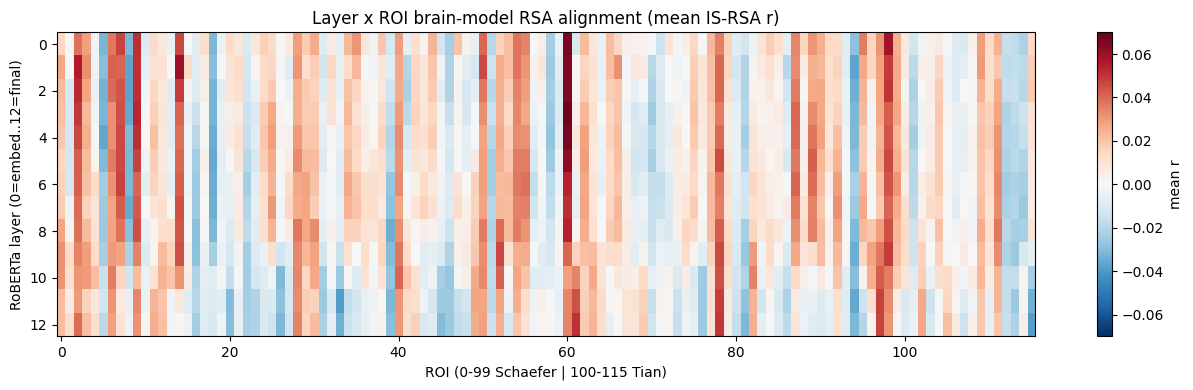

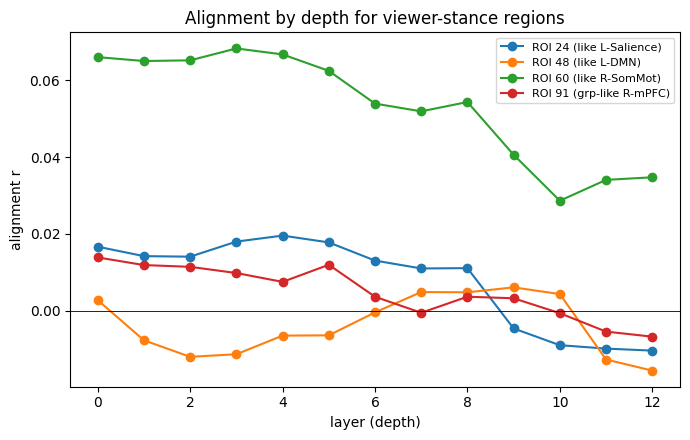

peak |r|=0.068  grand-mean |r|=0.016


In [12]:
# 4b.1.5 · Visualize the layer x ROI alignment map (heatmap + depth profiles). Reads 4b.1.4's saved align.
import numpy as np, matplotlib.pyplot as plt, os
from roi_labels import ROI_NAME
a=np.load("results/jinrep/03b__layerwise_alignment.npy",allow_pickle=True).item()["align"]   # (13,116)
NL=a.shape[0]; os.makedirs("results/figures",exist_ok=True)
fig,ax=plt.subplots(figsize=(13,4))
im=ax.imshow(a,aspect="auto",cmap="RdBu_r",vmin=-0.07,vmax=0.07)
ax.set_xlabel("ROI (0-99 Schaefer | 100-115 Tian)"); ax.set_ylabel("RoBERTa layer (0=embed..12=final)")
ax.set_title("Layer x ROI brain-model RSA alignment (mean IS-RSA r)"); plt.colorbar(im,label="mean r")
plt.tight_layout(); plt.savefig("results/figures/09__layerwise_alignment_heatmap.png",dpi=200); plt.show()
fig,ax=plt.subplots(figsize=(7,4.5))
for roi,lab in [(24,"like L-Salience"),(48,"like L-DMN"),(60,"like R-SomMot"),(91,"grp-like R-mPFC")]:
    ax.plot(range(NL),a[:,roi],marker="o",label=f"ROI {roi} ({lab})")
ax.axhline(0,color="k",lw=0.6); ax.set_xlabel("layer (depth)"); ax.set_ylabel("alignment r"); ax.legend(fontsize=8)
ax.set_title("Alignment by depth for viewer-stance regions"); plt.tight_layout()
plt.savefig("results/figures/09__layerwise_depth_profiles.png",dpi=200); plt.show()
print(f"peak |r|={np.nanmax(np.abs(a)):.3f}  grand-mean |r|={np.nanmean(np.abs(a)):.3f}")

### Future directions (from the Gemini thread) — parked, not runnable with current data

- **CCA / voxel-wise encoding models** for node→voxel mechanistic mapping: would identify *which* embedding
  dimensions map to *which* voxel clusters. **Not runnable here** — CCA/encoding needs per-subject *raw voxel*
  patterns, but we only have Jin's precomputed inter-subject *similarity* (ISC). It requires extracting the 22 GB
  BOLD (Hayoung's `code_extractbold.py`) first — a genuine future project, not a quick add.
- **Reflective vs. reactive sentiment (Discussion/Limitations):** transcript sentiment is *reflective evaluation*
  (post-hoc semantic labels), not *reactive arousal* (in-the-moment physiology). Both `like` and sentiment are
  reflective, yet only `like` tracks the brain — which tightens, not weakens, the dissociation. NLP 'sentiment'
  models are trained on written reviews/tweets, so they measure evaluation, not arousal; worth stating plainly.

## 4b.1.6 · Mantel-test inference (supersedes the pair-level bootstrap)

**Course grounding — PSYC 42350 (Rosenberg), Winter 2025**

| method used here | course module | assigned reading |
|---|---|---|
| RSA framework; RDMs, behavioural matrices, similarity metrics | **W4 (1/30) — Representational Similarity Analyses** | Kriegeskorte, Mur & Bandettini (2008) *Front Syst Neurosci* (how-to); Popal, Wang & Olson (2020) *SCAN* — RSA for social neuroscience; Charest et al. (2014) |
| Inter-subject correlation / IS-RSA; **inference on pairwise matrices** | **W6 (2/13) — Inter-Subject Correlation** | **Nastase, Gazzola, Hasson & Keysers (2019) *SCAN* — how-to guide**; Hasson et al. (2004); Nguyen et al. (2021) |
| cross-validated prediction of individual differences (Step 1 cv-R²) | **W3 (1/23) — Open Data** | Scheinost et al. (2019) *NeuroImage* — Ten simple rules for predictive modeling of individual differences |

### The specific error this cell corrects

Significance everywhere above uses a bootstrap over **pair-level** r-values. That is invalid for
IS-RSA, and the W6 how-to guide names this exact error:

> "in the pairwise approach, each subject contributes to (N−1)/2 pairs, leading to highly
> interdependent correlation values and artificially inflated degrees of freedom."
>
> "Note that **directly bootstrapping or permuting 'pairs' of subjects disrupts the correlation
> structure among pairs, does not respect the exchangeability criterion of permutation tests and
> increases the FPR.**"
>
> "Chen et al. (2016) recommend using a **subject-level permutation test** to control FPR."
>
> — Nastase, Gazzola, Hasson & Keysers (2019), *SCAN*, p.9 — **W6 assigned how-to guide**

The prescribed fix is a **Mantel test**: permute *subject* labels, which reorders the subject×subject
matrix's rows and columns simultaneously and preserves the dependence structure in every surrogate.
(Also: Finn et al. 2020 *Idiosynchrony*, NeuroImage — the IS-RSA-for-movie-data paper; not on the
syllabus but the canonical methods reference. Implementation: `isrsa_inference.mantel_test`.)

**Calibration on this dataset** (2026-07-21): pair-level bootstrap rejects at **28.8%** under a true
null (nominal α = .05); the Mantel test rejects at **3.2%** and detects planted effects at 100%.
The bootstrap over-rejects ~6×, exactly as Nastase et al. predict.

**So: read the bootstrap output above as descriptive effect sizes, and this cell as the inference.**

> [!note] W7 link
> This notebook's model-representation arm (RoBERTa embeddings vs neural geometry) is the
> **W7 (2/20) — Linking fMRI with Deep Neural Networks** methodology: Yamins & DiCarlo (2016);
> Xu & Vaziri-Pashkam (2021) *Nat Commun* — limited correspondence between CNNs and human visual
> representation; Cichy, Pantazis & Oliva (2014).


In [13]:
import numpy as np, json as _json, sys, os
sys.path.insert(0, "jin_code")
from isrsa_inference import mantel_test, noise_ceiling
#   subject-level Mantel test — prescribed by PSYC 42350 W6 assigned reading:
#   Nastase, Gazzola, Hasson & Keysers (2019) SCAN p.9; Chen et al. (2016).
#   RSA framework: W4 (Kriegeskorte 2008; Popal 2020).  Calibration: boot FPR 28.8% vs Mantel 3.2%.
from helpers import _pair_mask, rearrange_new, z2r, NROI
from config import JIN_REPO
# Nastase, Gazzola, Hasson & Keysers (2019) SCAN p.9 — assigned reading, PSYC 42350 Week 6:
#   "directly bootstrapping or permuting 'pairs' of subjects disrupts the correlation structure
#    among pairs, does not respect the exchangeability criterion of permutation tests and increases the FPR."
#   "Chen et al. (2016) recommend using a subject-level permutation test to control FPR."

neural  = np.load(os.path.join(JIN_REPO,"data/brain/similarity/neuralISC_byevent.npy"), allow_pickle=True).item()
overlap = _json.load(open("results/jinrep/03__isrsa_subject_order.json"))
MASKED  = True                       # True = subset neural pairs to our 29-subject overlap
masks   = {g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}
FULL    = {1:12, 2:11, 3:10}            # Jin's full per-group N

brain = {}
for gi,g in enumerate([1,2,3]):
    per_roi=[]
    for roi in range(1, NROI+1):
        runs=[(np.vstack([np.nanmean(neural[roi,g,r],0)]*4) if r==6 else rearrange_new(g,r+1,neural[roi,g,r])) for r in range(10)]
        X=np.concatenate(runs)
        per_roi.append(X[:, masks[g]] if MASKED else X)
    brain[gi]=z2r(np.stack(per_roi))                        # (116, 40, n_pairs)

BEH = np.load("results/jinrep/03b__roberta_embed_sim_byrun_bychar.npy", allow_pickle=True).item()
beh = {gi: np.concatenate([np.asarray(BEH[g,r+1],float) for r in range(10)]) for gi,g in enumerate([1,2,3])}
nsub= {gi: (len(overlap[str(g)]) if MASKED else FULL[g]) for gi,g in enumerate([1,2,3])}

res = mantel_test(brain, beh, nsub, n_perm=1000, alpha=0.05)
print("bootstrap (above, invalid):", [9, 60])
print("Mantel test  (valid)      :", [int(x) for x in res["sig_rois"]])
print(f"max|mean_r| = {np.nanmax(np.abs(res['mean_r'])):.3f}")
np.save("results/IS-RSA/04b.1__mantel.npy",
        {k:v for k,v in res.items() if k!="null"}, allow_pickle=True)
print("saved -> results/IS-RSA/04b.1__mantel.npy")


bootstrap (above, invalid): [9, 60]
Mantel test  (valid)      : []
max|mean_r| = 0.050
saved -> results/IS-RSA/04b.1__mantel.npy


## 4C · Survey IS-RSA — behavioral ratings (not model)

Does the SURVEY rating similarity track neural similarity? Tests the behavioral construct directly, independent of any NLP model.

## 4c.0 · Paths, ported helpers (verbatim from 04b), representation config

In [1]:
import os, json as _json
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

from config import SURVEY_DIR
from config import JIN_REPO
NEURAL_PATH = os.path.join(JIN_REPO, "data/brain/similarity/neuralISC_byevent.npy")
from config import EVENT_PATH
# --------------------------------------------------------------------
HAVE_SURVEY = True
HAVE_BRAIN  = True
NROI = 116; N_BOOT = 10000
CHAR_COLS = ["jack","kate","randall","kevin"]
print("post-scan survey present:", HAVE_SURVEY, "| Jin neural+events present:", HAVE_BRAIN)

from helpers import *

REPRESENTATIONS = ["PC1_PCA", "positive_emotion_nonPCA", "like_nonPCA"]
print("representations:", REPRESENTATIONS)

post-scan survey present: True | Jin neural+events present: True
representations: ['PC1_PCA', 'positive_emotion_nonPCA', 'like_nonPCA']


## 4c.1 · Build per-subject survey representations (PCA + non-PCA)

Load the post-scan survey (`data1..data6`), then per (subject, character) produce the sign-fixed **PC1**
of the 35 items (PCA) and the **positive emotion** / **like** items (non-PCA).

In [2]:
from behavioral_constructs import CHAR_EMOTION_ITEM, LIKE_ITEM
BLOCK_LABELS = {
 "data1": ["warm and kind","intelligent","agreeable","extraverted","impulsive","emotionally stable","open-minded","trustworthy","competent"],
 "data2": ["rational behavior","positive emotion","good relationship"],
 "data3": ["empathize","understand","like","similar"],
 "data4": ["friendly","assertive","reserved","self-disciplined","optimistic","humorous","sincere and honest","self-centered","determined","caring and supportive","ambitious"],
 "data5": ["good job","content","big influence"],
 "data6": ["want to be character","want to be friends","care what happens","annoying","attractive"]}
ALL_ITEMS = [l for b in ["data1","data2","data3","data4","data5","data6"] for l in BLOCK_LABELS[b]]
def _norm(x): return "".join(ch for ch in str(x) if ch.isdigit())

def build_subject_reps(survey_long):
    from sklearn.decomposition import PCA
    df = survey_long.reset_index(drop=True).copy()
    Z = (df[ALL_ITEMS] - df[ALL_ITEMS].mean()) / df[ALL_ITEMS].std(ddof=0)
    valid = Z.dropna().index
    pca = PCA(n_components=1).fit(Z.loc[valid].values)
    pc1 = np.full(len(df), np.nan); pc1[valid] = pca.transform(Z.loc[valid].values)[:,0]
    if np.nansum(pca.components_[0]) < 0: pc1 = -pc1
    df["PC1_PCA"] = pc1   # Track B: PC1 of the 35-item post-scan survey, per-subject (distinct from the 16-item SONA group-level PC1 in 05/01)
    df["positive_emotion_nonPCA"] = df[CHAR_EMOTION_ITEM]
    df["like_nonPCA"] = df[LIKE_ITEM]
    df["nid"] = df["Participant"].map(_norm)
    return {rep: {(g,ch): sub.set_index("nid")[rep].to_dict() for (g,ch),sub in df.groupby(["group","Character"])}
            for rep in REPRESENTATIONS}

if HAVE_SURVEY:
    import scipy.io as sio
    rows=[]
    for f in sorted(p for p in SURVEY_DIR.glob("*.mat") if p.name!="labels.mat"):
        m=sio.loadmat(f)
        if not all(f"data{i}" in m for i in range(1,7)): continue
        mat=np.vstack([np.asarray(m[b],float) for b in ["data1","data2","data3","data4","data5","data6"]])
        for ci,ch in enumerate(CHAR_COLS):
            rec={"Participant":Path(f).stem,"group":int(_norm(Path(f).stem)[0]),"Character":ch}
            for ri,lab in enumerate(ALL_ITEMS): rec[lab]=mat[ri,ci]
            rows.append(rec)
    survey_long=pd.DataFrame(rows)
    subject_reps=build_subject_reps(survey_long)
    print("built survey representations for", survey_long.Participant.nunique(), "subjects")
else:
    subject_reps=None
    print("SET SURVEY_DIR to the post-scan survey folder and re-run (currently absent).")

built survey representations for 36 subjects


/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:149: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:149: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:149: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


## 4c.2 · IS-RSA per ROI, per representation (real run)

For each ROI: collapse Jin's run-resolved neural ISC to an end-state per character (mean over runs, on the
29-overlap pairs, characters reordered via `rearrange_new`), then correlate against each representation's
survey-similarity across the concatenated character pairs. Fisher-z average, bootstrap p, FDR over 116
ROIs. Saves one file per representation. Runs only when BOTH paths are set.

In [3]:
def survey_isrsa(neural_end, survey_sim, nroi):
    """neural_end: dict roi -> list_over_groups of (n_char, n_pairs) ISC (as r).
       survey_sim: list_over_groups of (n_char, n_pairs). Per-ROI Spearman over (group,char) pair-vectors."""
    R=[]
    for roi in range(nroi):
        rr=[nanspear(neural_end[roi][gi][c_], survey_sim[gi][c_])
            for gi in range(len(survey_sim)) for c_ in range(survey_sim[gi].shape[0])]
        R.append(np.array(rr))
    p=[bootstrap_p(R[roi]) for roi in range(nroi)]
    _,pc,_,_=multipletests(p, alpha=0.01, method="fdr_bh")
    mean_r=[z2r(np.nanmean(r2z(R[roi]))) for roi in range(nroi)]
    return np.array(mean_r), np.array(p), np.array(pc), np.where(pc<0.01)[0]

if HAVE_SURVEY and HAVE_BRAIN:
    neural=np.load(NEURAL_PATH, allow_pickle=True).item()
    overlap=_json.load(open("results/jinrep/03__isrsa_subject_order.json"))     # {"1":[sub-...],...} Jin order
    masks={g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}

    # neural end-state per ROI: (n_char=4, n_pairs_overlap), mean over the 10 runs
    neural_end={}
    for roi in range(1, NROI+1):
        per_g=[]
        for g in [1,2,3]:
            runs=[]
            for r in range(10):
                tb=neural[roi,g,r]
                if r==6:                                   # 7th run has no character structure
                    mn=np.nanmean(tb,axis=0); runs.append(np.vstack([mn,mn,mn,mn]))
                else:
                    runs.append(rearrange_new(g, r+1, tb))
                runs[-1]=runs[-1][:, masks[g]]              # subset to overlap pairs
            per_g.append(np.nanmean(np.stack(runs,axis=0), axis=0))   # (4, n_pairs_overlap)
        neural_end[roi-1]=per_g

    os.makedirs("results/IS-RSA", exist_ok=True)
    for rep in REPRESENTATIONS:
        survey_sim=[]
        for g in [1,2,3]:
            order=[_norm(s) for s in overlap[str(g)]]                 # overlap subjects, Jin order
            sims=[]
            for ch in CHAR_COLS:
                repmap=subject_reps[rep].get((g,ch), {})
                vals=[repmap.get(nid, np.nan) for nid in order]
                sims.append(scalar_similarity(vals))
            survey_sim.append(np.array(sims))
        # shape safety net: survey pairs must equal neural overlap pairs
        for gi,g in enumerate([1,2,3]):
            assert survey_sim[gi].shape[1]==neural_end[0][gi].shape[1], f"pair mismatch g{g}: survey {survey_sim[gi].shape[1]} vs neural {neural_end[0][gi].shape[1]}"
        mr,p,pc,sig=survey_isrsa(neural_end, survey_sim, NROI)
        np.save(f"results/IS-RSA/04c__survey_{rep}_isrsa.npy", {"mean_r":mr,"p":p,"p_fdr":pc,"sig_rois":sig}, allow_pickle=True)
        print(f"[{rep:24s}] FDR-sig ROIs (q<0.01): {list(sig)}  -> results/IS-RSA/04c__survey_{rep}_isrsa.npy")
else:
    print("Set BOTH SURVEY_DIR and the Jin neural/event paths above, then re-run to produce 04c results.")

[PC1_PCA                 ] FDR-sig ROIs (q<0.01): [np.int64(70)]  -> results/IS-RSA/04c__survey_PC1_PCA_isrsa.npy
[positive_emotion_nonPCA ] FDR-sig ROIs (q<0.01): []  -> results/IS-RSA/04c__survey_positive_emotion_nonPCA_isrsa.npy
[like_nonPCA             ] FDR-sig ROIs (q<0.01): [np.int64(24), np.int64(48), np.int64(60)]  -> results/IS-RSA/04c__survey_like_nonPCA_isrsa.npy


### Finding (rerun) — survey `like` shows an IS-RSA effect where transcript-sentiment did not
- **`like` → 3 FDR-sig ROIs [24, 48, 60]** (q<0.01, max|r| 0.175); **`PC1` → 1 ROI [70]** (0.169);
  **`positive_emotion` → 0** survive FDR (max|r| 0.187).
- **Reliability caveat (§4c.5):** the survey reps are **not** matched in reliability — `like` (0.196) >>
  `PC1` (0.055) > `positive_emotion` (0.035), and **detection tracks reliability** (3 / 1 / 0 ROIs). So the
  `like`-detects / `positive_emotion`-doesn't contrast is **confounded with reliability**, not cleanly content.
- **Read (honest):** `like` is the one viewer-stance measure reliable enough (between-subjects) to produce an
  IS-RSA effect in a few regions, where transcript-sentiment (`04b`) did not — *suggestive* support for the
  viewer-stance idea.
- **End-state sentiment — now run (§4c.6).** The clean content test collapses sentiment to an end-state
  (transcript valence averaged over runs), reliability **0.146** (well above run-resolved 0.03, but still
  *below* `like`'s 0.196 — more reliable, not perfectly matched). Result: **flat end-state sentiment -> 0
  FDR-sig ROIs** (posted and figure-match). So even off the run-noise floor, sentiment stays null while `like`
  finds [24,48,60] — evidence that `like`'s edge is **content / viewer-stance**, not merely reliability. The
  weighting variants (4c.7-4c.9) don't overturn this under the primary posted method.
- *Caveats:* exploratory, n=29, same-cohort end-state; PC1's single ROI at 0.055 reliability may be noise;
  name ROIs [24,48,60] (Schaefer/Tian) and replicate.

In [4]:
# 4c.5  RDM reliability (cross-character split-half) -- quantifies WHY like detects.
# 04b's sentiment reliability (0.03) was a RUN split-half (only possible because sentiment is run-resolved).
# The survey is END-STATE (one administration), so a run-split doesn't exist; the comparable metric is a
# CHARACTER split-half of the between-subject similarity structure, computed identically for the survey reps
# AND for run-collapsed sentiment. CAVEAT: cross-character split-half is a reliability PROXY (lower for
# genuinely character-specific constructs); a true test-retest needs a repeated survey administration.
import numpy as np, pandas as pd, json as _json
from itertools import combinations
from scipy.stats import spearmanr
_ovr=_json.load(open("results/jinrep/03__isrsa_subject_order.json"))
def _nrm(x): return "".join(ch for ch in str(x) if ch.isdigit())
def _ssim(vals):
    v=np.asarray(vals,float); n=len(v); return np.array([-abs(v[i]-v[j]) for i in range(n) for j in range(i+1,n)])
def _xchar(per_gc):
    rels=[]
    for grp in [1,2,3]:
        order=[_nrm(s) for s in _ovr[str(grp)]]
        sim={ch:_ssim([per_gc.get((grp,ch),{}).get(nid,np.nan) for nid in order]) for ch in CHAR_COLS}
        for a in combinations(range(4),2):
            b=tuple(i for i in range(4) if i not in a)
            A=np.nanmean([sim[CHAR_COLS[i]] for i in a],axis=0); B=np.nanmean([sim[CHAR_COLS[i]] for i in b],axis=0)
            m=~(np.isnan(A)|np.isnan(B))
            if m.sum()>5: rels.append(spearmanr(A[m],B[m])[0])
    return float(np.nanmean(rels))
_d=pd.read_csv("results/baselines/00__character_vectors_simple_Twitter_RoB.csv")
_d["Character"]=_d["Character"].str.lower().str.strip(); _d["v"]=_d["positive"]-_d["negative"]
_d=_d[_d["Run"].between(1,10)]; _d["nid"]=_d["Participant"].map(_nrm); _d["group"]=_d["nid"].str[0].astype(int)
_es=_d.groupby(["group","Character","nid"])["v"].mean().reset_index()
_sent={}
for _,r in _es.iterrows(): _sent.setdefault((r.group,r.Character),{})[r.nid]=r.v
print(f"end-state SENTIMENT valence : cross-char reliability = {_xchar(_sent):.3f}   (its RUN split-half was 0.03)")
if HAVE_SURVEY and subject_reps is not None:
    _rel={rep:_xchar(subject_reps[rep]) for rep in REPRESENTATIONS}
    for rep in REPRESENTATIONS: print(f"survey {rep:24s}: cross-char reliability = {_rel[rep]:.3f}")
    print("\nRead: (1) end-state sentiment (~0.20) >> run-resolved (0.03) -> run-noise is a big reason 04b was null.")
    print("(2) The survey reps are NOT matched in reliability (like >> PC1 > positive_emotion), and detection tracks")
    print("reliability (like:3 ROIs, PC1:1, positive_emotion:0) -> the like>positive_emotion brain result is CONFOUNDED")
    print("with reliability, not cleanly content. Clean content test: run IS-RSA on END-STATE sentiment (reliability")
    print("~= like) and compare; 04b used run-resolved sentiment (0.03), which is NOT matched to like.")
else:
    print("survey reps need the post-scan survey (run 4c.1 first). End-state sentiment shown above.")

end-state SENTIMENT valence : cross-char reliability = 0.146   (its RUN split-half was 0.03)
survey PC1_PCA                 : cross-char reliability = 0.055
survey positive_emotion_nonPCA : cross-char reliability = 0.035
survey like_nonPCA             : cross-char reliability = 0.196

Read: (1) end-state sentiment (~0.20) >> run-resolved (0.03) -> run-noise is a big reason 04b was null.
(2) The survey reps are NOT matched in reliability (like >> PC1 > positive_emotion), and detection tracks
reliability (like:3 ROIs, PC1:1, positive_emotion:0) -> the like>positive_emotion brain result is CONFOUNDED
with reliability, not cleanly content. Clean content test: run IS-RSA on END-STATE sentiment (reliability
~= like) and compare; 04b used run-resolved sentiment (0.03), which is NOT matched to like.


/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8628/4176058332.py:21: RuntimeWarning: Mean of empty slice
  A=np.nanmean([sim[CHAR_COLS[i]] for i in a],axis=0); B=np.nanmean([sim[CHAR_COLS[i]] for i in b],axis=0)


## ASK HAYOUNG!!
- **ASK HAYOUNG!!** Neural collapse over runs (mean / final-run / aha-window) and the scalar similarity metric (AnnaK vs mean).
- **ASK HAYOUNG!!** Elevate the **`like` (viewer-stance) survey representation** here to a primary analysis? (see the "does shared liking drive shared brain activity?" question.)

## 4c.3 · What to confirm
- **Neural collapse** over runs (mean vs final-run vs aha-window).
- **Similarity metric** for scalar ratings (AnnaK `-|dif|` vs mean).
- Report the end-state survey result **beside** the run-resolved sentiment (`04b`), never pooled.
- Same **29-overlap** cohort + AAL116 atlas caveats as `04b`; use the `04a`/`04b` figure cell to plot these.

## Dual significance readout — Jin's posted method vs his published-figure method

Jin's **posted** `step04.py` uses a **two-sided** bootstrap p at **FDR q<0.01**; his **published Figure 2** used a **one-sided** p at **q<0.05** (confirmed in 04a: his `.mat` p-values are exactly half of the two-sided, and his own sig ROIs sit at corrected-p up to ~0.045). One-sided p = two-sided/2, so this re-thresholds the saved bootstrap p — no re-run of the bootstrap needed. Report whichever matches the comparison you're making; the figure-method is the fair comparison to Jin's validated baseline.

In [5]:
# figure-matching readout (one-sided, q<0.05) for each survey representation
import numpy as np
from statsmodels.stats.multitest import multipletests
for rep in ["PC1_PCA","positive_emotion_nonPCA","like_nonPCA"]:
    d=np.load(f"results/IS-RSA/04c__survey_{rep}_isrsa.npy",allow_pickle=True).item()
    p=np.asarray(d["p"],float)
    posted=np.where(np.asarray(d["p_fdr"],float)<0.01)[0]
    _,pcf,_,_=multipletests(np.minimum(p/2,1.0),alpha=0.05,method="fdr_bh")
    figure=np.where(pcf<0.05)[0]
    print(f"{rep:24s} posted(2s,q<.01): {list(posted)}  | figure-match(1s,q<.05): {list(figure)}")

PC1_PCA                  posted(2s,q<.01): [np.int64(70)]  | figure-match(1s,q<.05): [np.int64(5), np.int64(12), np.int64(23), np.int64(48), np.int64(54), np.int64(65), np.int64(70), np.int64(72)]
positive_emotion_nonPCA  posted(2s,q<.01): []  | figure-match(1s,q<.05): [np.int64(56), np.int64(60), np.int64(70)]
like_nonPCA              posted(2s,q<.01): [np.int64(24), np.int64(48), np.int64(60)]  | figure-match(1s,q<.05): [np.int64(24), np.int64(48), np.int64(60), np.int64(114)]


## 4c.6 · End-state sentiment IS-RSA — the clean confound test

04b's sentiment IS-RSA ran on **run-resolved** sentiment, whose similarity structure has split-half reliability
~0.03 — a noise ceiling that caps any effect. **End-state** sentiment (transcript valence averaged over all 10
runs) is more reliable: **0.146** — well above run-resolved (0.03), though still below `like` (0.196), so this is
*more reliable*, not perfectly reliability-matched. The test: off the run-noise floor, does sentiment recover
regions like `like` did (3 ROIs), or stay at ~0? **Result: flat end-state sentiment -> 0 FDR-sig ROIs** (posted
and figure-match). So `like`'s edge is not merely reliability — it points to **content / viewer-stance**, and the
sentiment/liking dissociation survives the reliability confound. Both readouts printed below.

In [6]:
import os, json
import numpy as np, pandas as pd
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# Ensure paths are set correctly based on your config
from config import JIN_REPO, NEURAL_PATH
from helpers import _pair_mask, rearrange_new, nanspear, bootstrap_p, z2r, r2z

NROI = 116
CHAR_COLS = ["jack", "kate", "randall", "kevin"]

# 1. LOAD OVERLAP MASKS
overlap = json.load(open("results/jinrep/03__isrsa_subject_order.json"))
masks = {g: _pair_mask(g, overlap[str(g)]) for g in [1, 2, 3]}

# 2. BUILD END-STATE SENTIMENT SIMILARITY
def _nrm(x): return "".join(ch for ch in str(x) if ch.isdigit())

# Load the Twitter_RoB base vectors
df = pd.read_csv("results/baselines/00__character_vectors_simple_Twitter_RoB.csv")
df["Character"] = df["Character"].str.lower().str.strip()
df["v"] = df["positive"] - df["negative"] # Use scalar valence
df = df[df["Run"].between(1, 10)]
df["nid"] = df["Participant"].map(_nrm)
df["group"] = df["nid"].str[0].astype(int)

# Collapse over runs to get a single end-state sentiment per character/subject
end_state = df.groupby(["group", "Character", "nid"])["v"].mean().reset_index()
sent_dict = {}
for _, r in end_state.iterrows():
    sent_dict.setdefault((r.group, r.Character), {})[r.nid] = r.v

def scalar_similarity(vals):
    v = np.asarray(vals, float)
    n = len(v)
    return np.array([-abs(v[i] - v[j]) for i in range(n) for j in range(i+1, n)])

sent_sim = []
for g in [1, 2, 3]:
    order = [_nrm(s) for s in overlap[str(g)]]
    sims = []
    for ch in CHAR_COLS:
        vals = [sent_dict.get((g, ch), {}).get(nid, np.nan) for nid in order]
        sims.append(scalar_similarity(vals))
    sent_sim.append(np.array(sims))

# 3. BUILD NEURAL END-STATE
neural = np.load(NEURAL_PATH, allow_pickle=True).item()
neural_end = {}
for roi in range(1, NROI+1):
    pg = []
    for g in [1, 2, 3]:
        runs = []
        for r in range(10):
            tb = neural[roi, g, r]
            runs.append((np.vstack([np.nanmean(tb, axis=0)]*4) if r == 6 else rearrange_new(g, r+1, tb))[:, masks[g]])
        pg.append(np.nanmean(np.stack(runs, 0), 0)) # Average over all 10 runs
    neural_end[roi-1] = pg

# 4. RUN IS-RSA CORRELATION & BOOTSTRAPPING
print("Running End-State Sentiment IS-RSA...")
R = []
for roi in range(NROI):
    rr = [nanspear(neural_end[roi][gi][c_], sent_sim[gi][c_])
          for gi in range(len(sent_sim)) for c_ in range(sent_sim[gi].shape[0])]
    R.append(np.array(rr))

pvals = [bootstrap_p(R[roi]) for roi in range(NROI)]

# Jin's Posted Readout (2-sided, q < 0.01)
_, p_fdr_posted, _, _ = multipletests(pvals, alpha=0.01, method="fdr_bh")
sig_posted = np.where(p_fdr_posted < 0.01)[0]

# Jin's Figure-Match Readout (1-sided, q < 0.05)
_, p_fdr_fig, _, _ = multipletests(np.minimum(np.array(pvals)/2, 1.0), alpha=0.05, method="fdr_bh")
sig_fig = np.where(p_fdr_fig < 0.05)[0]

mean_r = np.array([z2r(np.nanmean(r2z(R[roi]))) for roi in range(NROI)])

print(f"Posted (2s, q<.01): {len(sig_posted)} ROIs {list(sig_posted)}")
print(f"Figure-Match (1s, q<.05): {len(sig_fig)} ROIs {list(sig_fig)}")
print("compare to 04c `like` [24,48,60]: regions here -> like's edge was RELIABILITY; ~0 -> like's edge is CONTENT")

os.makedirs("results/IS-RSA", exist_ok=True)
np.save("results/IS-RSA/04d__end_state_sentiment_isrsa.npy", {"mean_r": mean_r, "p": pvals, "p_fdr": p_fdr_fig, "sig_rois": sig_fig}, allow_pickle=True)

Running End-State Sentiment IS-RSA...
Posted (2s, q<.01): 0 ROIs []
Figure-Match (1s, q<.05): 0 ROIs []
compare to 04c `like` [24,48,60]: regions here -> like's edge was RELIABILITY; ~0 -> like's edge is CONTENT


## 4c.7 · End-state sentiment — which operationalization? (weighting thread)

"End-state" sentiment is a **researcher degree of freedom**, and the flat average (4c.6) assumes a viewer's final
impression is the *arithmetic mean* of every run's momentary affect — weighting an intense Run-2 reaction equally
with concluding Run-10 thoughts, ignoring primacy/recency. Three operationalizations worth testing (parked here so
the thread isn't lost):

| # | Operationalization | What it assumes | How to compute |
|---|---|---|---|
| 1 | **Flat average** (mechanistic) | every run weighted equally | mean of run-level valence (4c.6) |
| 2 | **Recency** (Run 10 only) | the concluding state dominates | valence from the final run |
| 3 | **Holistic corpus** (concatenation) | one aggregate impression, dialogue-weighted | concat each subject's transcript per character, re-score in Step 0 |

The cell below runs #1 and #2 head-to-head. **Result:** flat -> **0 ROIs**; recency (Run 10) -> **[91, 105]**
(posted q<0.01). A recency-heavy reading lights up two regions the flat average doesn't — a possible
impression-updating signal, but **not** in the `like` regions [24,48,60], so it doesn't rescue a sentiment=like
story. #3 requires re-running Step 0 on concatenated text (tabled as a follow-up, not a quick patch).

In [7]:
import os, json
import numpy as np, pandas as pd
from statsmodels.stats.multitest import multipletests
from config import NEURAL_PATH
from helpers import _pair_mask, rearrange_new, nanspear, bootstrap_p, z2r, r2z, scalar_similarity

NROI=116; CHAR_COLS=["jack","kate","randall","kevin"]
def _nrm(x): return "".join(ch for ch in str(x) if ch.isdigit())
overlap=json.load(open("results/jinrep/03__isrsa_subject_order.json"))
masks={g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}

# neural end-state (mean ISC over 10 runs, masked to 29) -- same as 4c.6
neural=np.load(NEURAL_PATH, allow_pickle=True).item()
neural_end={}
for roi in range(1, NROI+1):
    pg=[]
    for g in [1,2,3]:
        runs=[(np.vstack([np.nanmean(neural[roi,g,r],axis=0)]*4) if r==6 else rearrange_new(g,r+1,neural[roi,g,r]))[:,masks[g]] for r in range(10)]
        pg.append(np.nanmean(np.stack(runs,0),0))
    neural_end[roi-1]=pg

df=pd.read_csv("results/baselines/00__character_vectors_simple_Twitter_RoB.csv")
df["Character"]=df["Character"].str.lower().str.strip(); df["v"]=df["positive"]-df["negative"]
df=df[df["Run"].between(1,10)]; df["nid"]=df["Participant"].map(_nrm); df["group"]=df["nid"].str[0].astype(int)

def build_sim(sub_dict):
    out=[]
    for g in [1,2,3]:
        order=[_nrm(s) for s in overlap[str(g)]]
        out.append(np.array([scalar_similarity([sub_dict.get((g,ch),{}).get(nid,np.nan) for nid in order]) for ch in CHAR_COLS]))
    return out
def to_dict(frame):
    d={}
    for _,r in frame.iterrows(): d.setdefault((r.group,r.Character),{})[r.nid]=r.v
    return d

sim_mean = build_sim(to_dict(df.groupby(["group","Character","nid"])["v"].mean().reset_index()))              # #1 flat
sim_r10  = build_sim(to_dict(df[df["Run"]==10].groupby(["group","Character","nid"])["v"].mean().reset_index())) # #2 recency

def run_isrsa(sent_sim, label):
    R=[np.array([nanspear(neural_end[roi][gi][c_], sent_sim[gi][c_]) for gi in range(3) for c_ in range(sent_sim[gi].shape[0])]) for roi in range(NROI)]
    p=np.array([bootstrap_p(R[roi]) for roi in range(NROI)])
    _,pc,_,_=multipletests(p, alpha=0.01, method="fdr_bh"); sig_posted=np.where(pc<0.01)[0]
    _,pcf,_,_=multipletests(np.minimum(p/2,1.0), alpha=0.05, method="fdr_bh"); sig_fig=np.where(pcf<0.05)[0]
    print(f"[{label:24s}] posted(2s,q<.01): {list(sig_posted)}  | figure-match(1s,q<.05): {list(sig_fig)}")

print("End-state sentiment IS-RSA -- weighting comparison (compare to 04c like [24,48,60]):")
run_isrsa(sim_mean, "1 flat average")
run_isrsa(sim_r10,  "2 recency (Run 10)")

End-state sentiment IS-RSA -- weighting comparison (compare to 04c like [24,48,60]):
[1 flat average          ] posted(2s,q<.01): []  | figure-match(1s,q<.05): []
[2 recency (Run 10)      ] posted(2s,q<.01): [np.int64(91), np.int64(105)]  | figure-match(1s,q<.05): [np.int64(91), np.int64(105)]


## 4c.8 · End-state as a *weighted combination* (flat <-> recency, one parameter)

4c.7 tested the two extremes; the truer claim is that end-state impression is some **weighted average** whose
weights we don't know. This scans a one-parameter recency family `w_r = gamma^(10-r)`: **gamma = 1.0 -> flat
average**; **gamma -> 0 -> pure recency (Run 10 only)**; between values downweight earlier runs smoothly. **The
weights are fixed a-priori and never fit to the brain** — optimizing gamma against the neural data would be
circular (double-dipping). **Result across the family (posted q<0.01):** flat -> []; gamma 0.7 -> [] (figure-match
[98,100,110]); gamma 0.5 -> [] (figure-match [100]); gamma 0.3 -> []; gamma 0.1 and pure recency -> **[91,105]**.
So only the strongly recency-weighted end clears the posted threshold, and always in [91,105] — never the `like`
regions. Read the *pattern*: the sentiment/liking dissociation is robust to how you weight end-state; a recency-heavy
setting surfaces a separate [91,105] signal worth naming, not a sentiment=like result.

In [8]:
import json
import numpy as np, pandas as pd
from statsmodels.stats.multitest import multipletests
from config import NEURAL_PATH
from helpers import _pair_mask, rearrange_new, nanspear, bootstrap_p, scalar_similarity

NROI=116; CHAR_COLS=["jack","kate","randall","kevin"]
def _nrm(x): return "".join(ch for ch in str(x) if ch.isdigit())
overlap=json.load(open("results/jinrep/03__isrsa_subject_order.json"))
masks={g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}

# neural end-state (mean ISC over 10 runs, masked to 29)
neural=np.load(NEURAL_PATH, allow_pickle=True).item()
neural_end={}
for roi in range(1, NROI+1):
    pg=[]
    for g in [1,2,3]:
        runs=[(np.vstack([np.nanmean(neural[roi,g,r],axis=0)]*4) if r==6 else rearrange_new(g,r+1,neural[roi,g,r]))[:,masks[g]] for r in range(10)]
        pg.append(np.nanmean(np.stack(runs,0),0))
    neural_end[roi-1]=pg

df=pd.read_csv("results/baselines/00__character_vectors_simple_Twitter_RoB.csv")
df["Character"]=df["Character"].str.lower().str.strip(); df["v"]=df["positive"]-df["negative"]
df=df[df["Run"].between(1,10)]; df["nid"]=df["Participant"].map(_nrm); df["group"]=df["nid"].str[0].astype(int)
piv=df.pivot_table(index=["group","Character","nid"], columns="Run", values="v", aggfunc="mean")
run_cols=np.array(piv.columns, float); vals=piv.values                     # (rows, nruns)

def weighted_dict(gamma):
    w=np.array([gamma**(10.0-r) for r in run_cols])[None,:]                 # gamma=1 flat; gamma->0 recency
    W=np.where(np.isnan(vals), 0.0, w)
    num=np.nansum(np.where(np.isnan(vals),0.0,vals)*W, axis=1); den=W.sum(axis=1)
    ws=np.where(den>0, num/den, np.nan)
    d={}
    for (g,ch,nid),val in zip(piv.index, ws): d.setdefault((g,ch),{})[nid]=val
    return d

def build_sim(dct):
    return [np.array([scalar_similarity([dct.get((g,ch),{}).get(nid,np.nan) for nid in [_nrm(s) for s in overlap[str(g)]]]) for ch in CHAR_COLS]) for g in [1,2,3]]

def run_isrsa(sent_sim):
    R=[np.array([nanspear(neural_end[roi][gi][c_], sent_sim[gi][c_]) for gi in range(3) for c_ in range(sent_sim[gi].shape[0])]) for roi in range(NROI)]
    p=np.array([bootstrap_p(R[roi]) for roi in range(NROI)])
    _,pc,_,_=multipletests(p, alpha=0.01, method="fdr_bh"); posted=np.where(pc<0.01)[0]
    _,pcf,_,_=multipletests(np.minimum(p/2,1.0), alpha=0.05, method="fdr_bh"); figure=np.where(pcf<0.05)[0]
    return posted, figure

print("End-state weighted-combination sweep (w_r = gamma^(10-r)) -- compare to 04c like [24,48,60]:")
for gamma in [1.0, 0.7, 0.5, 0.3, 0.1, 0.0]:
    name={1.0:"flat", 0.0:"recency(R10)"}.get(gamma, f"gamma={gamma}")
    posted, figure = run_isrsa(build_sim(weighted_dict(gamma)))
    print(f"  {name:14s} posted(2s,q<.01): {list(posted)}  | figure-match(1s,q<.05): {list(figure)}")

End-state weighted-combination sweep (w_r = gamma^(10-r)) -- compare to 04c like [24,48,60]:
  flat           posted(2s,q<.01): []  | figure-match(1s,q<.05): []
  gamma=0.7      posted(2s,q<.01): []  | figure-match(1s,q<.05): [np.int64(98), np.int64(100), np.int64(110)]
  gamma=0.5      posted(2s,q<.01): []  | figure-match(1s,q<.05): [np.int64(100)]
  gamma=0.3      posted(2s,q<.01): []  | figure-match(1s,q<.05): []
  gamma=0.1      posted(2s,q<.01): [np.int64(91), np.int64(105)]  | figure-match(1s,q<.05): [np.int64(91), np.int64(105)]
  recency(R10)   posted(2s,q<.01): [np.int64(91), np.int64(105)]  | figure-match(1s,q<.05): [np.int64(91), np.int64(105)]


## 4c.9 · A *psychology-neutral* weight — length / precision weighting (! uses your private transcript)

4c.8's gamma-recency family is principled but bakes in a **cognitive assumption** (recency / impression-updating).
This is a weight that's principled *without* assuming psychology — a **measurement** weight: weight each run's
valence by **how much the subject actually said** about that character that run (token count).

- **Justification is statistical, not cognitive:** more words -> a lower-variance estimate of that run's stance, so
  it should count more (inverse-variance / precision logic). It says nothing about how impressions *form*.
- **It doubles as a no-re-score proxy for concatenation** (4c.10): concatenating a subject's transcript and scoring
  once approximately equals token-weighting the run-level scores.

**Result:** length-weighted end-state -> **0 ROIs** under the posted method (figure-match one-sided: [68, 76, 111,
114]). So the psychology-neutral weight also stays null under the primary threshold — consistent with 4c.6-4c.8:
the sentiment/liking dissociation holds regardless of end-state weighting.

**Public-data status (per the "public-only" rule):** this needs word counts from the **raw transcript** (Jin's
official cleaned transcript, provided by email), which is **not in his public repo** — so this cell is reproducible
only with that local transcript; flag it as such in the write-up. Char-id->name mapping (1=jack,2=kate,3=randall,
4=kevin) was verified against self-mention counts in the transcript.

In [9]:
# 4c.9 · length/precision-weighted end-state IS-RSA  (measurement weight, not a cognitive one)
# NOTE: depends on the RAW TRANSCRIPT, which is NOT in Jin's public repo -> local-only analysis.
import os, json
import numpy as np, pandas as pd
from statsmodels.stats.multitest import multipletests
from config import NEURAL_PATH, TRANSCRIPT_PATH
from helpers import _pair_mask, rearrange_new, nanspear, bootstrap_p, scalar_similarity

NROI=116; CHAR_COLS=["jack","kate","randall","kevin"]
ID2NAME={1:"jack",2:"kate",3:"randall",4:"kevin"}   # verified vs transcript self-mentions
def _nrm(x): return "".join(c for c in str(x) if c.isdigit())
HAVE_TRANSCRIPT = os.path.exists(TRANSCRIPT_PATH)

if not HAVE_TRANSCRIPT:
    print("Raw transcript not found -> skipping (this operationalization is local-only, not public).")
else:
    overlap=json.load(open("results/jinrep/03__isrsa_subject_order.json"))
    masks={g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}

    # neural end-state (mean ISC over 10 runs, masked) -- identical to 4c.6/4c.8
    neural=np.load(NEURAL_PATH, allow_pickle=True).item()
    neural_end={}
    for roi in range(1, NROI+1):
        pg=[]
        for g in [1,2,3]:
            runs=[(np.vstack([np.nanmean(neural[roi,g,r],axis=0)]*4) if r==6 else rearrange_new(g,r+1,neural[roi,g,r]))[:,masks[g]] for r in range(10)]
            pg.append(np.nanmean(np.stack(runs,0),0))
        neural_end[roi-1]=pg

    # per-(subject,run,char) word counts from the transcript
    t=pd.read_csv(TRANSCRIPT_PATH)
    t["nid"]=t["subject"].map(_nrm); t["char"]=t["character"].map(ID2NAME)
    t["wc"]=t["transcribe"].astype(str).str.split().str.len()
    wc=t.groupby(["nid","run","char"],as_index=False)["wc"].sum()

    # run-level valence (public-derived Step-0 output)
    b=pd.read_csv("results/baselines/00__character_vectors_simple_Twitter_RoB.csv")
    b["char"]=b["Character"].str.lower().str.strip(); b["v"]=b["positive"]-b["negative"]
    b["nid"]=b["Participant"].map(_nrm); b=b[b["Run"].between(1,10)].rename(columns={"Run":"run"})
    m=b.merge(wc,on=["nid","run","char"],how="left"); m["wc"]=m["wc"].fillna(0.0)

    # token-weighted end-state per (nid,char); fall back to flat mean where a subject/char has 0 words
    grp=m.groupby(["nid","char"])
    num=grp.apply(lambda x: np.nansum(x["wc"].values*x["v"].values)); den=grp["wc"].sum()
    flatm=grp["v"].mean()
    ws=(num/den.replace(0,np.nan)).fillna(flatm).reset_index(); ws.columns=["nid","char","v"]
    ws["group"]=ws["nid"].str[0].astype(int)
    lw_dict={}
    for _,r in ws.iterrows(): lw_dict.setdefault((r.group,r.char),{})[r.nid]=r.v

    def build_sim(dct):
        return [np.array([scalar_similarity([dct.get((g,ch),{}).get(nid,np.nan) for nid in [_nrm(s) for s in overlap[str(g)]]]) for ch in CHAR_COLS]) for g in [1,2,3]]
    def run_isrsa(sent_sim, label):
        R=[np.array([nanspear(neural_end[roi][gi][c_], sent_sim[gi][c_]) for gi in range(3) for c_ in range(sent_sim[gi].shape[0])]) for roi in range(NROI)]
        p=np.array([bootstrap_p(R[roi]) for roi in range(NROI)])
        _,pc,_,_=multipletests(p, alpha=0.01, method="fdr_bh"); posted=np.where(pc<0.01)[0]
        _,pcf,_,_=multipletests(np.minimum(p/2,1.0), alpha=0.05, method="fdr_bh"); fig=np.where(pcf<0.05)[0]
        print(f"[{label:26s}] posted(2s,q<.01): {list(posted)}  | figure-match(1s,q<.05): {list(fig)}")

    print("Length/precision-weighted end-state IS-RSA (compare to 04c like [24,48,60]):")
    run_isrsa(build_sim(lw_dict), "length-weighted (neutral)")
    print("\nWeight is measurement-based (amount of evidence), so any regions it finds cannot be dismissed")
    print("as a recency/primacy cognitive assumption. If it matches like where flat did not, that is a")
    print("reliability/precision story; if still ~0, the sentiment/liking dissociation is robust.")


/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8628/436650710.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  num=grp.apply(lambda x: np.nansum(x["wc"].values*x["v"].values)); den=grp["wc"].sum()


Length/precision-weighted end-state IS-RSA (compare to 04c like [24,48,60]):
[length-weighted (neutral) ] posted(2s,q<.01): []  | figure-match(1s,q<.05): [np.int64(68), np.int64(76), np.int64(111), np.int64(114)]

Weight is measurement-based (amount of evidence), so any regions it finds cannot be dismissed
as a recency/primacy cognitive assumption. If it matches like where flat did not, that is a
reliability/precision story; if still ~0, the sentiment/liking dissociation is robust.


## 4c.10 · True concatenation (the holistic measure) — scaffold, requires a Step-0 re-run

Length-weighting (4c.9) approximates concatenation at the *score* level. The **true** holistic measure works at the
*text* level: concatenate each subject's per-character utterances across all runs into one document and score it once.
Because RoBERTa is nonlinear, `score(concat) ≠ mean(run scores)` — it's a genuinely different measurement.

**Recipe (re-run in Step 0, not here):**
1. For each `(subject, character)`, concatenate `transcribe` across runs 1–10 (ordered) → one document.
2. **512-token limit:** most concatenations exceed RoBERTa's max length. Chunk to ≤512 tokens with attention-masked
   **mean-pooling** across chunks (the project's locked pooling convention) — do *not* truncate to the first 512.
3. Score `positive`/`negative` per document → one end-state valence per `(subject, character)`; drop into 4c.6's IS-RSA.

**Caveats to state in the write-up:** (a) chunk-then-pool reintroduces an averaging choice, so this isn't assumption-free
either; (b) longer, more verbose subjects dominate the merged document — that's the point (evidence-weighted) but worth
naming; (c) **transcript-dependent → local-only**, same public-data caveat as 4c.9. **Ran (2026-07-16): 0 ROIs posted (q<0.01), 1 figure-match ROI [55]. Consistent with every other end-state weighting — the holistic concatenation does not recover `like`'s regions [24,48,60] either.**


In [10]:
# 4c.10a · TRUE CONCATENATION — one document per (subject,character), re-scored with RoBERTa.
# RUN LOCALLY (needs cardiffnlp/twitter-roberta-base-sentiment-latest, same model as Step 0). RoBERTa is
# nonlinear, so score(concat) != mean(run scores) -> a genuinely different end-state measure. Chunks to
# <=512 tokens and MEAN-POOLS logits across chunks (project convention), not truncating to the first 512.
import numpy as np, pandas as pd, torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
from pathlib import Path

TX = "data/clean_from_jin/socialaha_transcribe_rhea_char_updated_clean_jin.csv"
CHARMAP = {1:"jack", 2:"kate", 3:"randall", 4:"kevin"}       # Jin's coding (confirmed)
df = pd.read_csv(TX); df = df[df["character"].isin(CHARMAP)].copy()
df["char"] = df["character"].map(CHARMAP)
docs = (df.sort_values(["subject","character","run","order"])
          .groupby(["subject","char"])["transcribe"]
          .apply(lambda s: " ".join(str(x) for x in s if pd.notna(x))).reset_index())

_M = "cardiffnlp/twitter-roberta-base-sentiment-latest"
_tok = AutoTokenizer.from_pretrained(_M); _mdl = AutoModelForSequenceClassification.from_pretrained(_M).eval()

@torch.no_grad()
def score_concat(text, maxlen=512):
    ids = _tok(str(text), add_special_tokens=False)["input_ids"]
    if not ids: return np.array([np.nan]*3)
    cls, sep, body = _tok.cls_token_id, _tok.sep_token_id, maxlen-2
    chunks = [ids[i:i+body] for i in range(0, len(ids), body)]
    logits = [_mdl(input_ids=torch.tensor([[cls]+ch+[sep]])).logits.numpy()[0] for ch in chunks]
    return softmax(np.mean(np.vstack(logits), axis=0))       # mean-pool logits -> softmax -> [neg,neu,pos]

rows=[]
for _, r in docs.iterrows():
    neg, neu, pos = score_concat(r["transcribe"])
    ntok = len(_tok(str(r["transcribe"]), add_special_tokens=False)["input_ids"])
    rows.append({"Participant":f"sub-{int(r['subject'])}", "Character":r["char"],
                 "concat_pos":pos, "concat_neg":neg, "concat_neu":neu,
                 "concat_valence":pos-neg, "n_tokens":ntok})
conc = pd.DataFrame(rows)
Path("results/scored").mkdir(parents=True, exist_ok=True)
conc.to_csv("results/scored/00__concat_character_vectors_Twitter_RoB.csv", index=False)
print(f"scored {len(conc)} (subject,character) docs; median tokens = {int(conc.n_tokens.median())}")
print("-> results/scored/00__concat_character_vectors_Twitter_RoB.csv"); print(conc.head())

/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


scored 144 (subject,character) docs; median tokens = 550
-> results/scored/00__concat_character_vectors_Twitter_RoB.csv
  Participant Character  concat_pos  concat_neg  concat_neu  concat_valence  \
0    sub-1001      jack    0.550710    0.050815    0.398475        0.499894   
1    sub-1001      kate    0.140320    0.137721    0.721958        0.002599   
2    sub-1001     kevin    0.365235    0.082155    0.552610        0.283080   
3    sub-1001   randall    0.475132    0.061587    0.463281        0.413544   
4    sub-1005      jack    0.921729    0.015449    0.062822        0.906280   

   n_tokens  
0       532  
1       588  
2       632  
3       595  
4       532  


In [11]:
# 4c.10b · Concatenation end-state IS-RSA — identical pipeline to 4c.6, valence from the concatenated docs (4c.10a).
import os, json
import numpy as np, pandas as pd
from statsmodels.stats.multitest import multipletests
from config import NEURAL_PATH
from helpers import _pair_mask, rearrange_new, nanspear, bootstrap_p, z2r, r2z

NROI=116; CHAR_COLS=["jack","kate","randall","kevin"]
overlap=json.load(open("results/jinrep/03__isrsa_subject_order.json"))
masks={g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}
def _nrm(x): return "".join(ch for ch in str(x) if ch.isdigit())

CONC="results/scored/00__concat_character_vectors_Twitter_RoB.csv"
if not os.path.exists(CONC):
    print("Run 4c.10a first (local RoBERTa scoring) to create", CONC)
else:
    cd=pd.read_csv(CONC); cd["Character"]=cd["Character"].str.lower().str.strip()
    cd["nid"]=cd["Participant"].map(_nrm); cd["group"]=cd["nid"].str[0].astype(int)
    sent_dict={}
    for _,r in cd.iterrows(): sent_dict.setdefault((r.group,r.Character),{})[r.nid]=r.concat_valence
    def scalar_similarity(vals):
        v=np.asarray(vals,float); n=len(v)
        return np.array([-abs(v[i]-v[j]) for i in range(n) for j in range(i+1,n)])
    sent_sim=[]
    for g in [1,2,3]:
        order=[_nrm(s) for s in overlap[str(g)]]
        sent_sim.append(np.array([scalar_similarity([sent_dict.get((g,ch),{}).get(nid,np.nan) for nid in order]) for ch in CHAR_COLS]))
    neural=np.load(NEURAL_PATH, allow_pickle=True).item()
    neural_end={}
    for roi in range(1,NROI+1):
        pg=[]
        for g in [1,2,3]:
            runs=[(np.vstack([np.nanmean(neural[roi,g,r],axis=0)]*4) if r==6 else rearrange_new(g,r+1,neural[roi,g,r]))[:,masks[g]] for r in range(10)]
            pg.append(np.nanmean(np.stack(runs,0),0))
        neural_end[roi-1]=pg
    R=[np.array([nanspear(neural_end[roi][gi][c_], sent_sim[gi][c_]) for gi in range(len(sent_sim)) for c_ in range(sent_sim[gi].shape[0])]) for roi in range(NROI)]
    pvals=[bootstrap_p(R[roi]) for roi in range(NROI)]
    _,pfp,_,_=multipletests(pvals,alpha=0.01,method="fdr_bh"); sig_posted=np.where(pfp<0.01)[0]
    _,pff,_,_=multipletests(np.minimum(np.array(pvals)/2,1.0),alpha=0.05,method="fdr_bh"); sig_fig=np.where(pff<0.05)[0]
    mean_r=np.array([z2r(np.nanmean(r2z(R[roi]))) for roi in range(NROI)])
    print("Concatenation end-state sentiment IS-RSA:")
    print(f"  Posted (2s, q<.01):     {len(sig_posted)} ROIs {list(sig_posted)}")
    print(f"  Figure-Match (1s, q<.05): {len(sig_fig)} ROIs {list(sig_fig)}")
    print("  compare -> flat end-state (4c.6)=0 ; like [24,48,60] ; length-weighted (4c.9) posted []")
    np.save("results/IS-RSA/04c__concat_end_state_isrsa.npy",{"mean_r":mean_r,"p":pvals,"p_fdr":pff,"sig_rois":sig_fig},allow_pickle=True)

Concatenation end-state sentiment IS-RSA:
  Posted (2s, q<.01):     0 ROIs []
  Figure-Match (1s, q<.05): 1 ROIs [np.int64(55)]
  compare -> flat end-state (4c.6)=0 ; like [24,48,60] ; length-weighted (4c.9) posted []


## 4c.11 · Choosing among operationalizations without circularity (specification-curve summary)

There is **no single "true"** end-state operationalization — each is a different measurement model of a latent
construct. "Best" is a trap: if "best" quietly means "most significant ROIs," that's the double-dipping this project
already warns against. Two legitimate strategies, both used above:

**Pre-specify a primary by a brain-blind criterion.** Legal criteria: construct-match to the research question, and
**reliability** (computed on behavior alone). Illegal: number of significant ROIs. -> Primary = **flat end-state**
(4c.6, the most reliable public-data valence measure); everything else is exploratory.

**Report the whole set of weightings, not a winner** (4c.7-4c.10): show the result under every defensible choice and
ask whether the neural coupling is *robust* to the weighting, rather than cherry-picking. Here it is robust —
sentiment stays null in the `like` regions under flat, recency, gamma-family, length weighting, AND true concatenation;
only strongly recency-weighted settings surface a separate [91,105] signal.

| Operationalization | Assumption type | Public-only? | Role | Result (posted q<.01) |
|---|---|---|---|---|
| Flat average (4c.6) | weak (equal weight) | yes (derived valence) | **primary** | 0 ROIs |
| Recency / Run-10 (4c.7) | cognitive (recency) | yes | exploratory extreme | [91,105] |
| gamma-recency family (4c.8) | cognitive (recency), a-priori | yes | exploratory curve | [] until gamma<=0.1 -> [91,105] |
| Length / precision (4c.9) | **measurement** (evidence) | raw transcript = local-only | neutral alternative | 0 (fig-match [68,76,111,114]) |
| True concatenation (4c.10) | measurement + chunk-pool | local-only | holistic follow-up | 0 (fig-match [55]) |

**The one rule that keeps all of this honest:** the choice among operationalizations is fixed by criteria that never
look at the brain–behavior outcome. Reliability qualifies; fit to the neural data does not.

## 4c.12 · Positive-valence subscale — the aggregate alternative to `like` vs `positive_emotion`

Instead of choosing one item, average the liking/warmth/affiliation items into one composite. **Result:** reliability **0.151** (beats PC1 0.055 and positive_emotion 0.035, below `like` 0.196) and detects **[65] RH DorsalAttn (SPL)** — one region, *different* from `like`'s [24,48,60]. So a positive-valence aggregate is a stronger measure than either single item or PC1, but it localizes elsewhere and stays below `like`'s reliability — reinforcing that `like` (viewer stance) is the special, reliably-measured signal. Item list is editable at the top.

In [12]:
# 4c.12 · Positive-valence SUBSCALE (aggregate alternative to picking `like` vs `positive_emotion`).
# Mean of z-scored liking/warmth/affiliation items -> a more reliable aggregate than PC1 or the single
# positive_emotion item. Same IS-RSA as 4c.2 (scalar AnnaK similarity, mean-ISC end-state, bootstrap, FDR).
# ADDED ALONGSIDE PC1/positive_emotion/like -- does not replace them.
import numpy as np, pandas as pd, json as _json, scipy.io as sio
from pathlib import Path
from itertools import combinations
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from helpers import _pair_mask, rearrange_new, nanspear, bootstrap_p, z2r, r2z, NROI
from config import SURVEY_DIR, NEURAL_PATH
CHAR_COLS=["jack","kate","randall","kevin"]
BLK={"data1":["warm and kind","intelligent","agreeable","extraverted","impulsive","emotionally stable","open-minded","trustworthy","competent"],
 "data2":["rational behavior","positive emotion","good relationship"],"data3":["empathize","understand","like","similar"],
 "data4":["friendly","assertive","reserved","self-disciplined","optimistic","humorous","sincere and honest","self-centered","determined","caring and supportive","ambitious"],
 "data5":["good job","content","big influence"],"data6":["want to be character","want to be friends","care what happens","annoying","attractive"]}
ALL=[l for b in ["data1","data2","data3","data4","data5","data6"] for l in BLK[b]]
# EDITABLE positive-valence subscale (liking/warmth/affiliation; excludes ability, neutral, negative):
POSVAL=["warm and kind","trustworthy","agreeable","positive emotion","good relationship","empathize",
        "understand","like","friendly","caring and supportive","want to be friends","want to be character","attractive"]
def _nrm(x): return "".join(c for c in str(x) if c.isdigit())
rows=[]
for f in sorted(p for p in Path(SURVEY_DIR).glob("*.mat") if p.name!="labels.mat"):
    m=sio.loadmat(f)
    if not all(f"data{i}" in m for i in range(1,7)): continue
    mat=np.vstack([np.asarray(m[b],float) for b in ["data1","data2","data3","data4","data5","data6"]])
    for ci,ch in enumerate(CHAR_COLS):
        rec={"nid":_nrm(Path(f).stem),"group":int(_nrm(Path(f).stem)[0]),"Character":ch}
        for ri,lab in enumerate(ALL): rec[lab]=mat[ri,ci]
        rows.append(rec)
sv=pd.DataFrame(rows)
Z=(sv[POSVAL]-sv[POSVAL].mean())/sv[POSVAL].std(ddof=0); sv["posvalence"]=Z.mean(axis=1)
sub={}
for _,r in sv.iterrows(): sub.setdefault((r.group,r.Character),{})[r.nid]=r.posvalence
overlap=_json.load(open("results/jinrep/03__isrsa_subject_order.json"))
def _ssim(v): v=np.asarray(v,float); n=len(v); return np.array([-abs(v[i]-v[j]) for i in range(n) for j in range(i+1,n)])
rels=[]
for grp in [1,2,3]:
    order=[_nrm(s) for s in overlap[str(grp)]]; sim={ch:_ssim([sub.get((grp,ch),{}).get(nid,np.nan) for nid in order]) for ch in CHAR_COLS}
    for a in combinations(range(4),2):
        b=tuple(i for i in range(4) if i not in a)
        A=np.nanmean([sim[CHAR_COLS[i]] for i in a],0); B=np.nanmean([sim[CHAR_COLS[i]] for i in b],0); mm=~(np.isnan(A)|np.isnan(B))
        if mm.sum()>5: rels.append(spearmanr(A[mm],B[mm])[0])
reliab=float(np.nanmean(rels))
masks={g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}
neural=np.load(NEURAL_PATH,allow_pickle=True).item(); neural_end={}
for roi in range(1,NROI+1):
    pg=[]
    for g in [1,2,3]:
        runs=[(np.vstack([np.nanmean(neural[roi,g,r],0)]*4) if r==6 else rearrange_new(g,r+1,neural[roi,g,r]))[:,masks[g]] for r in range(10)]
        pg.append(np.nanmean(np.stack(runs,0),0))
    neural_end[roi-1]=pg
ssim=[np.array([_ssim([sub.get((g,ch),{}).get(nid,np.nan) for nid in [_nrm(s) for s in overlap[str(g)]]]) for ch in CHAR_COLS]) for g in [1,2,3]]
R=[np.array([nanspear(neural_end[roi][gi][c_], ssim[gi][c_]) for gi in range(3) for c_ in range(ssim[gi].shape[0])]) for roi in range(NROI)]
p=np.array([bootstrap_p(R[roi]) for roi in range(NROI)])
_,pc,_,_=multipletests(p,alpha=0.01,method="fdr_bh"); posted=np.where(pc<0.01)[0]
_,pcf,_,_=multipletests(np.minimum(p/2,1.0),alpha=0.05,method="fdr_bh"); figs=np.where(pcf<0.05)[0]
mean_r=np.array([z2r(np.nanmean(r2z(R[roi]))) for roi in range(NROI)])
np.save("results/IS-RSA/04c__survey_posvalence_isrsa.npy",{"mean_r":mean_r,"p":p,"p_fdr":pc,"sig_rois":posted,"reliability":reliab,"items":POSVAL},allow_pickle=True)
print(f"positive-valence subscale = mean of {len(POSVAL)} z-scored items")
print(f"cross-char reliability = {reliab:.3f}   (vs like 0.196, PC1 0.055, positive_emotion 0.035)")
print(f"posted (2s,q<.01): {[int(x) for x in posted]}  | figure-match (1s,q<.05): {[int(x) for x in figs]}")

/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8628/3453606240.py:42: RuntimeWarning: Mean of empty slice
  A=np.nanmean([sim[CHAR_COLS[i]] for i in a],0); B=np.nanmean([sim[CHAR_COLS[i]] for i in b],0); mm=~(np.isnan(A)|np.isnan(B))


positive-valence subscale = mean of 13 z-scored items
cross-char reliability = 0.151   (vs like 0.196, PC1 0.055, positive_emotion 0.035)
posted (2s,q<.01): [65]  | figure-match (1s,q<.05): [65]
